In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)

# consistent colors
COLORS = {
    'human': '#34495e',
    'ai': '#e67e22',
    'success': "#2bbb67",
    'fail': "#d14030",
    'patch_fail': '#7f8c8d'
}

# trying to match LaTeX font
plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 150,
    'savefig.dpi': 300
})

print("Environment configured.")

Environment configured.


In [ ]:
# metric definition and loading

csv_path = 'llm_bug_analysis/results/results_final.csv'

# load data
headers = pd.read_csv(csv_path, nrows=0).columns.tolist()
exclude_keywords = ['body', 'message', 'formatted_context', 'patch_content', 'raw_response']
cols_to_keep = [c for c in headers if not any(kw in c for kw in exclude_keywords)]

df = pd.read_csv(csv_path, usecols=cols_to_keep)

# numeric conversion
numeric_cols = [
    'ai_lines_added', 'ai_lines_deleted', 'ai_total_diff',
    'complexity_after_llm_cc', 'complexity_after_human_cc',
    'llm_thinking_tokens', 'llm_total_tokens',
    'llm_tests_passed_count', 'human_tests_passed_count'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# evaluation
def categorize_result(row):
    if row.get('llm_patch_applied') != True:
        return 'Patch gen. failed'
    
    human_score = row['human_tests_passed_count']
    llm_score = row['llm_tests_passed_count']
    
    if human_score == 0:
        return 'Infrastructure fail'
    
    if llm_score >= human_score:
        return 'Success'
    
    return 'Tests failed'

df['Outcome'] = df.apply(categorize_result, axis=1)

# filter out infrastructure failures when calculating llm success rates
valid_df = df[df['Outcome'] != 'Infrastructure fail'].copy()

# complexity deltas (only for valid comparisons)
valid_df['delta_complexity'] = valid_df['complexity_after_llm_cc'] - valid_df['complexity_after_human_cc']

print(f"Total Rows: {len(df)}")
print("\nOutcome distribution:")
print(df['Outcome'].value_counts())

print(f"Row count before dedup: {len(df)}")
df = df.drop_duplicates(subset=['repo_name', 'bug_commit_sha'], keep='last')
print(f"Row count after dedup: {len(df)}")

Total Rows: 627

Outcome distribution:
Outcome
Tests failed           283
Infrastructure fail    146
Success                111
Patch gen. failed       87
Name: count, dtype: int64
Row count before dedup: 627
Row count after dedup: 627


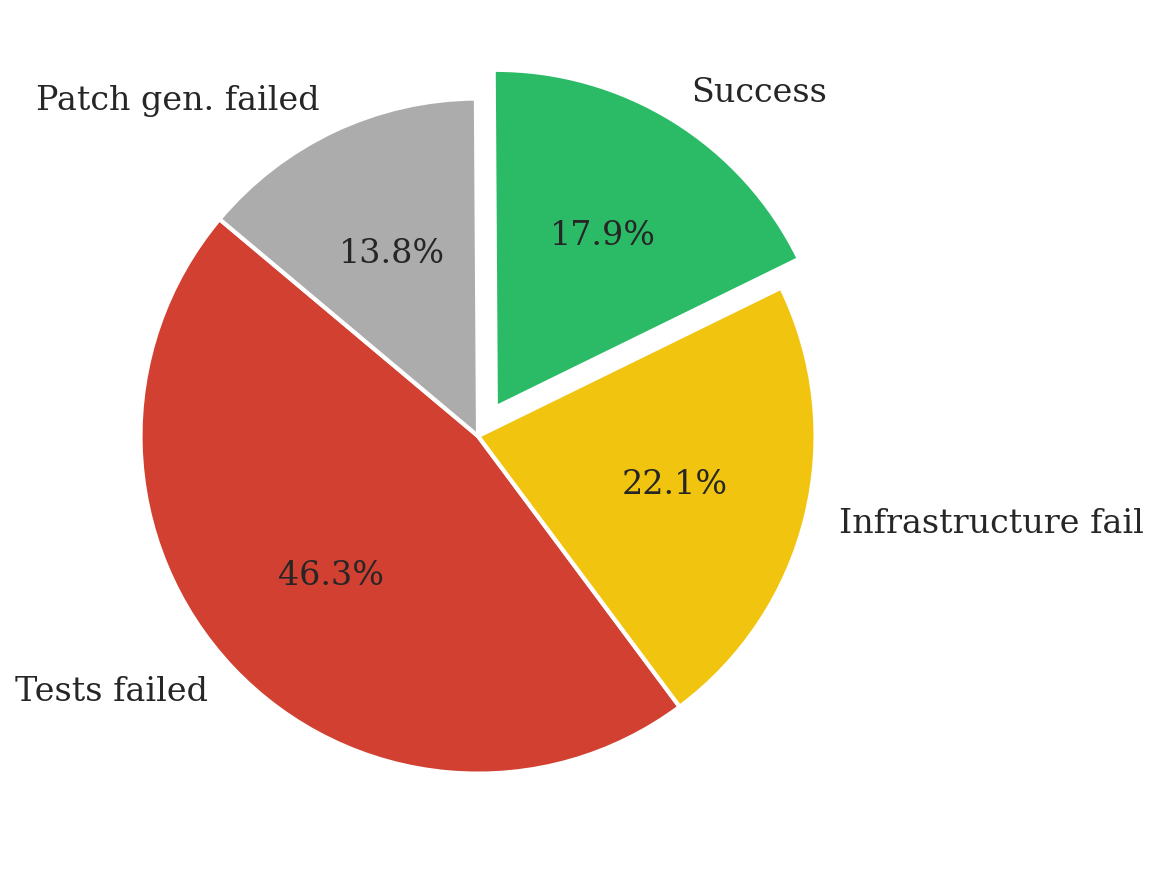

In [ ]:
# pie chart

# full dataframe here to show infra issues
outcome_counts = df['Outcome'].value_counts()

# colors for the new category
colors_map = {
    'Success': COLORS['success'],           # green
    'Tests failed': COLORS['fail'],         # red
    'Patch gen. failed': "#ACACAC",            # gray
    'Infrastructure fail': '#f1c40f'        # yellow (warning)
}

# colors match the order of the data
pie_colors = [colors_map[key] for key in outcome_counts.index]

plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, 
        labels=outcome_counts.index.tolist(), 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=pie_colors,
        textprops={'fontsize': 16},
        explode=[0.1 if 'Success' in idx else 0 for idx in outcome_counts.index], # pop out success
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# plt.title("Breakdown of all bug-fix attempts", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_funnel_strict.pdf")
plt.savefig("figures/fig_funnel_strict.png")
plt.show()

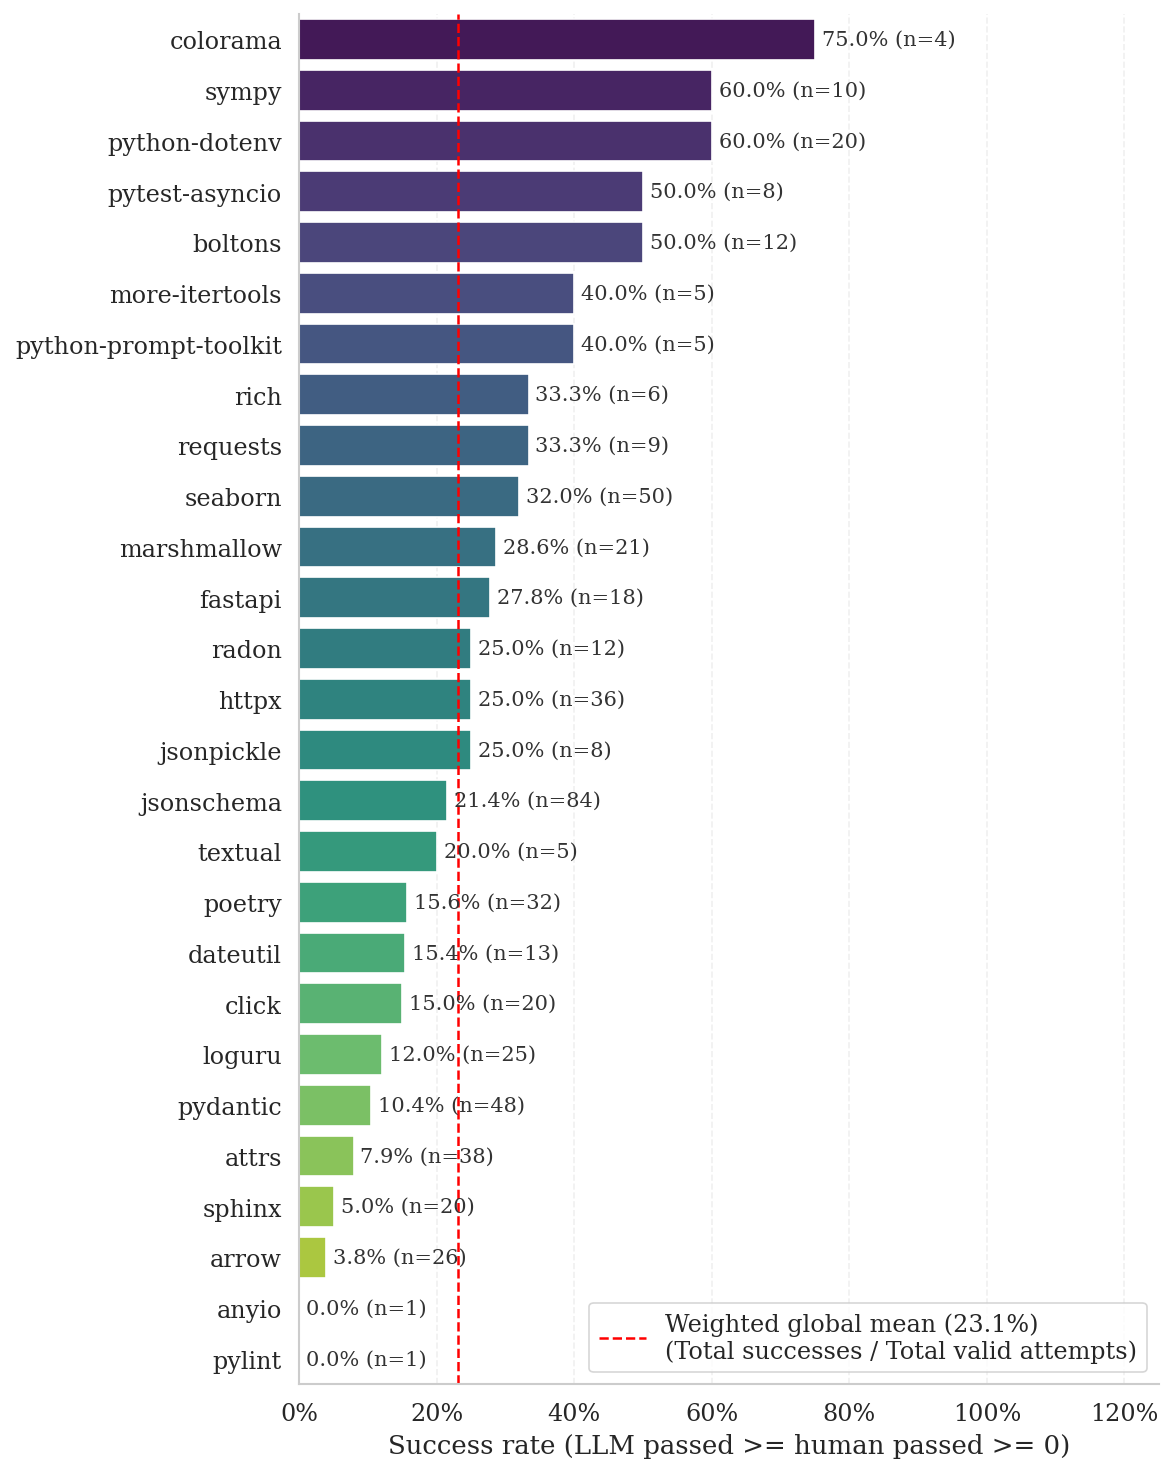

In [ ]:
# bar plot for each repo

# aggregation
repo_stats = df.groupby('repo_name').agg({
    'bug_commit_sha': 'count',
    'Outcome': lambda x: x.value_counts().to_dict()
}).reset_index()

# extract counts
def extract_counts(row):
    counts = row['Outcome']
    success = counts.get('Success', 0)
    infra_fail = counts.get('Infrastructure fail', 0)
    total = row['bug_commit_sha']
    
    valid_attempts = total - infra_fail
    rate = (success / valid_attempts) if valid_attempts > 0 else 0.0
    
    return pd.Series([valid_attempts, rate])

repo_stats[['Valid attempts', 'Success rate']] = repo_stats.apply(extract_counts, axis=1)

# filter and clean data
plot_stats = repo_stats[repo_stats['Valid attempts'] >= 0].sort_values('Success rate', ascending=False)
plot_stats = plot_stats.dropna(subset=['Success rate'])  # remove any nan values
plot_stats['short_name'] = plot_stats['repo_name'].apply(lambda x: x.split('/')[-1])

global_success_rate = valid_df['Outcome'].value_counts(normalize=True)['Success']

# plot
plt.figure(figsize=(8, 10))
ax = sns.barplot(
    data=plot_stats,
    y="short_name",
    x='Success rate',
    hue="short_name",
    palette="viridis",
    legend=False,
    edgecolor=None
)

for i, (index, row) in enumerate(plot_stats.iterrows()):
    n_count = int(row['Valid attempts'])
    percentage = row['Success rate']
    
    label_text = f"{percentage:.1%} (n={n_count})"
    
    ax.text(
        percentage + 0.01,       # x pos
        i,                       # y pos
        label_text, 
        va='center',
        ha='left',
        fontsize=10,
        color='#333333'
    )

# formatting
from matplotlib.ticker import PercentFormatter
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.axvline(global_success_rate, color='red', linestyle='--', 
            label=f'Weighted global mean ({global_success_rate:.1%})\n(Total successes / Total valid attempts)')
plt.legend(loc='lower right')

# plt.title("Strict success rate (excluding infrastructure failures)", fontweight='bold', pad=20, loc="center")
# plt.suptitle("Strict success rate (excluding infrastructure failures)", fontweight='bold', y=0.98)
plt.xlabel("Success rate (LLM passed >= human passed >= 0)")
plt.ylabel("")
plt.xlim(0, 1.25) 

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_repo_success_strict.pdf")
# plt.savefig("/home/vesco/thesis/latex/figures/fig_repo_success_strict.png")
plt.show()

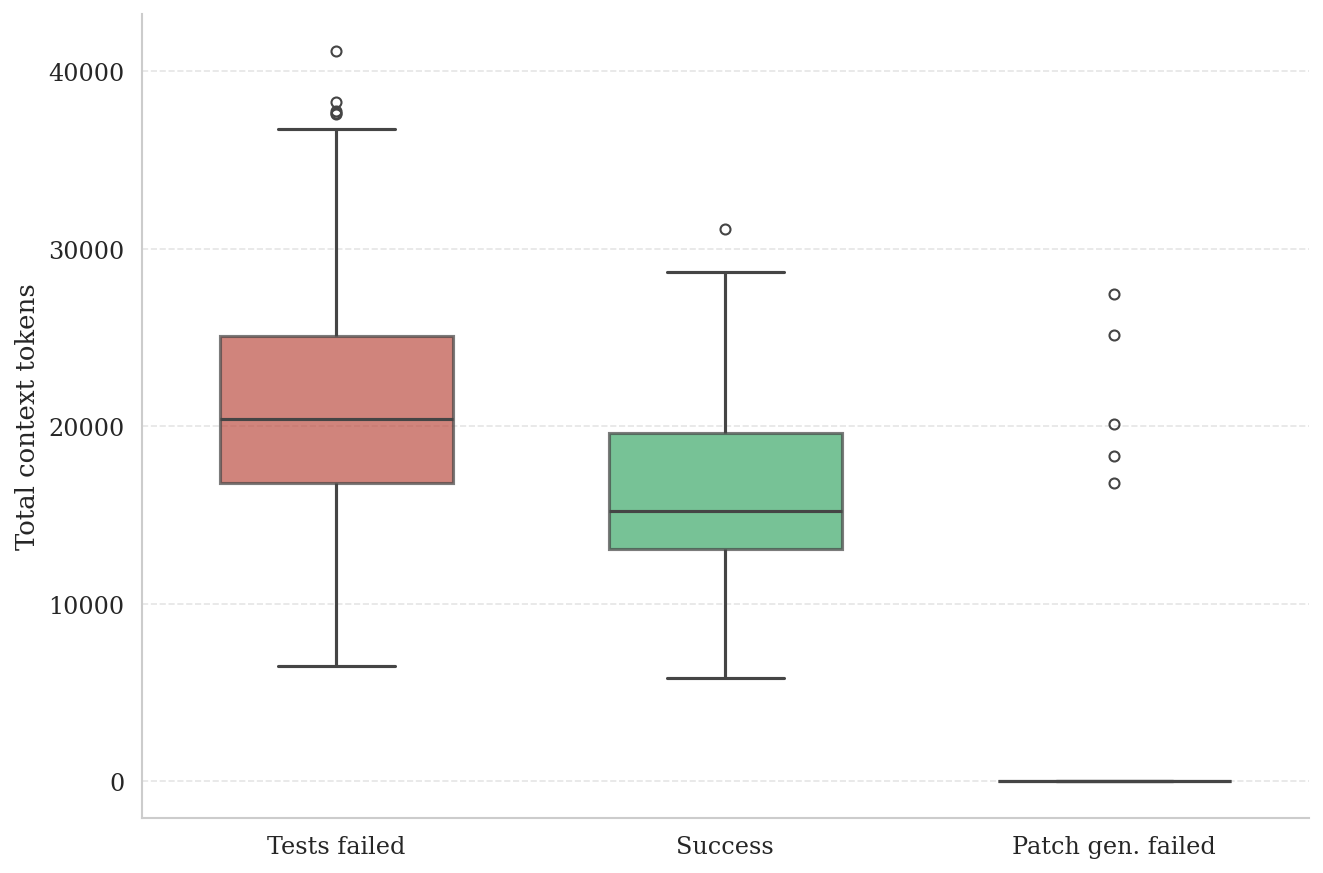

In [ ]:
# context size vs outcome

plt.figure(figsize=(9, 6))

# only look at valid llm attempts
# want to see if context size caused patch gen gailure or test failure
context_df = valid_df[valid_df['Outcome'].isin(['Success', 'Tests failed', 'Patch gen. failed'])]

palette = {
    'Success': COLORS['success'], 
    'Tests failed': COLORS['fail'],
    'Patch gen. failed': COLORS['patch_fail']
}

sns.boxplot(
    data=context_df, 
    x='Outcome', 
    y='llm_total_tokens',
    hue='Outcome',
    palette=palette, 
    width=0.6, 
    linewidth=1.5,
    boxprops=dict(alpha=0.7)
)

# plt.title("Effect of context length on AI performance", fontweight='bold')
plt.ylabel("Total context tokens")
plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_context_impact.pdf")
plt.savefig("figures/fig_context_impact.png")
plt.show()

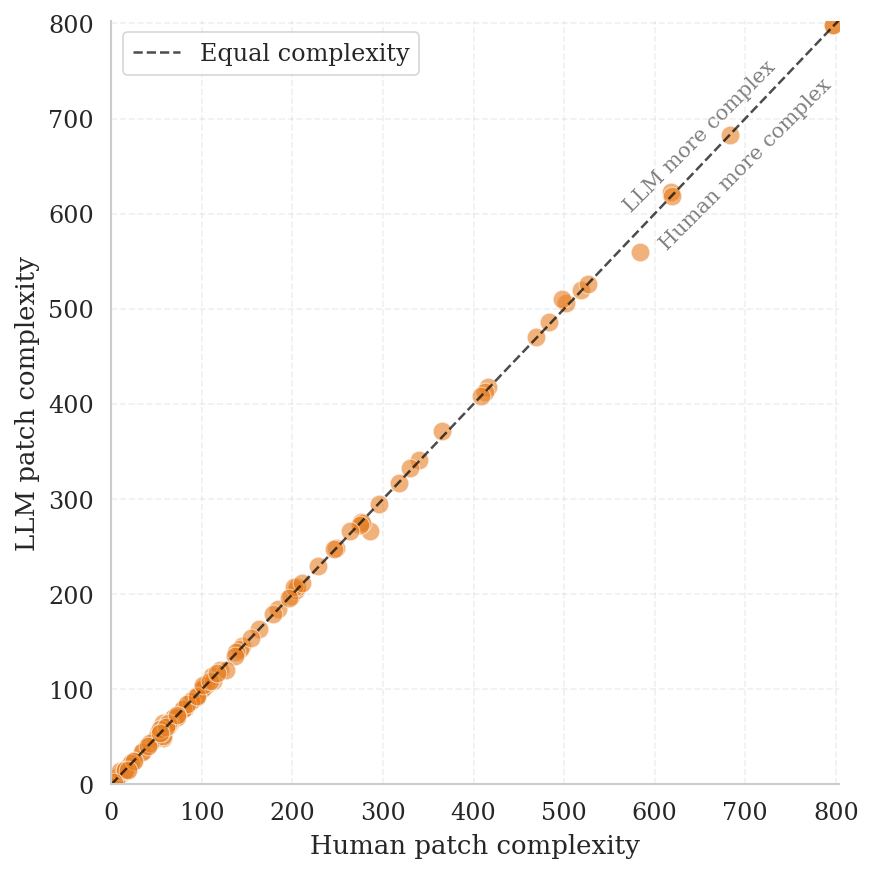

In [ ]:
# complexity comparison scatter plot

# only successful fixes from valid runs
success_df = valid_df[valid_df['Outcome'] == 'Success']

plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=success_df, 
    x='complexity_after_human_cc', 
    y='complexity_after_llm_cc',
    color=COLORS['ai'], 
    alpha=0.6, 
    s=80, 
    edgecolor='white',
    linewidth=0.5
)

# identity line (y=x)
max_val = max(success_df['complexity_after_human_cc'].max(), success_df['complexity_after_llm_cc'].max()) + 5
plt.plot([0, max_val], [0, max_val], linestyle='--', color='black', alpha=0.7, label='Equal complexity')

# annotations
plt.text(max_val*0.7, max_val*0.75, "LLM more complex", fontsize=10, color='gray', rotation=45)
plt.text(max_val*0.75, max_val*0.7, "Human more complex", fontsize=10, color='gray', rotation=45)

# plt.title("Cyclomatic complexity: Human vs. LLM (Successful fixes)", fontweight='bold')
plt.xlabel("Human patch complexity")
plt.ylabel("LLM patch complexity")
plt.legend()
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_complexity_scatter.pdf")
plt.savefig("figures/fig_complexity_scatter.png")
plt.show()

In [ ]:
# summary table export

# aggregation
summary_table = df.groupby('repo_name').apply(lambda x: pd.Series({
    'Total bugs': len(x),
    'Infra fails': (x['Outcome'] == 'Infrastructure Fail').sum(),
    'Valid attempts': (x['Outcome'] != 'Infrastructure Fail').sum(),
    'Patch gen. fails': (x['Outcome'] == 'Patch Gen. Failed').sum(),
    'AI fixed': (x['Outcome'] == 'Success').sum(),
    'Avg tokens': x['llm_total_tokens'].mean()
}))

# on valid attempts only
summary_table['Success rate'] = (summary_table['AI fixed'] / summary_table['Valid attempts']) * 100

# sort by volume and rate
summary_table = summary_table.sort_values(['Valid attempts', 'Success rate'], ascending=False)

# clean up nan (div by zero)
summary_table = summary_table.fillna(0)

display(summary_table)

/tmp/ipykernel_25179/1718044728.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_table = df.groupby('repo_name').apply(lambda x: pd.Series({


,Total bugs,Infra fails,Valid attempts,Patch gen. fails,AI fixed,Avg tokens,Success rate
repo_name,,,,,,,
mwaskom/seaborn,50.0,0.0,50.0,0.0,16.0,19138.460000,32.000000
encode/httpx,50.0,0.0,50.0,0.0,9.0,16064.380000,18.000000
pydantic/pydantic,50.0,0.0,50.0,0.0,5.0,22463.900000,10.000000
Delgan/loguru,50.0,0.0,50.0,0.0,3.0,18037.080000,6.000000
python-attrs/attrs,50.0,0.0,50.0,0.0,3.0,15659.660000,6.000000
python-poetry/poetry,40.0,0.0,40.0,0.0,5.0,18059.450000,12.500000
arrow-py/arrow,38.0,0.0,38.0,0.0,1.0,16496.078947,2.631579
marshmallow-code/marshmallow,35.0,0.0,35.0,0.0,6.0,12986.914286,17.142857
python-jsonschema/jsonschema,31.0,0.0,31.0,0.0,6.0,16502.774194,19.354839



--- LaTeX code for thesis ---

\begin{tabular}{lrrrrrr}
\toprule
 & Total bugs & Infra fails & Valid attempts & AI fixed & Avg tokens & Success rate \\
repo_name &  &  &  &  &  &  \\
\midrule
mwaskom/seaborn & 50 & 0 & 50 & 16 & 19138.5 & 32.0 \\
encode/httpx & 50 & 0 & 50 & 9 & 16064.4 & 18.0 \\
pydantic/pydantic & 50 & 0 & 50 & 5 & 22463.9 & 10.0 \\
Delgan/loguru & 50 & 0 & 50 & 3 & 18037.1 & 6.0 \\
python-attrs/attrs & 50 & 0 & 50 & 3 & 15659.7 & 6.0 \\
python-poetry/poetry & 40 & 0 & 40 & 5 & 18059.5 & 12.5 \\
arrow-py/arrow & 38 & 0 & 38 & 1 & 16496.1 & 2.6 \\
marshmallow-code/marshmallow & 35 & 0 & 35 & 6 & 12986.9 & 17.1 \\
python-jsonschema/jsonschema & 31 & 0 & 31 & 6 & 16502.8 & 19.4 \\
mahmoud/boltons & 30 & 0 & 30 & 6 & 17298.9 & 20.0 \\
rubik/radon & 23 & 0 & 23 & 3 & 13000.7 & 13.0 \\
theskumar/python-dotenv & 22 & 0 & 22 & 12 & 15627.7 & 54.5 \\
pallets/click & 20 & 0 & 20 & 3 & 17011.7 & 15.0 \\
sphinx-doc/sphinx & 20 & 0 & 20 & 1 & 19726.5 & 5.0 \\
pylint-dev/pylint &

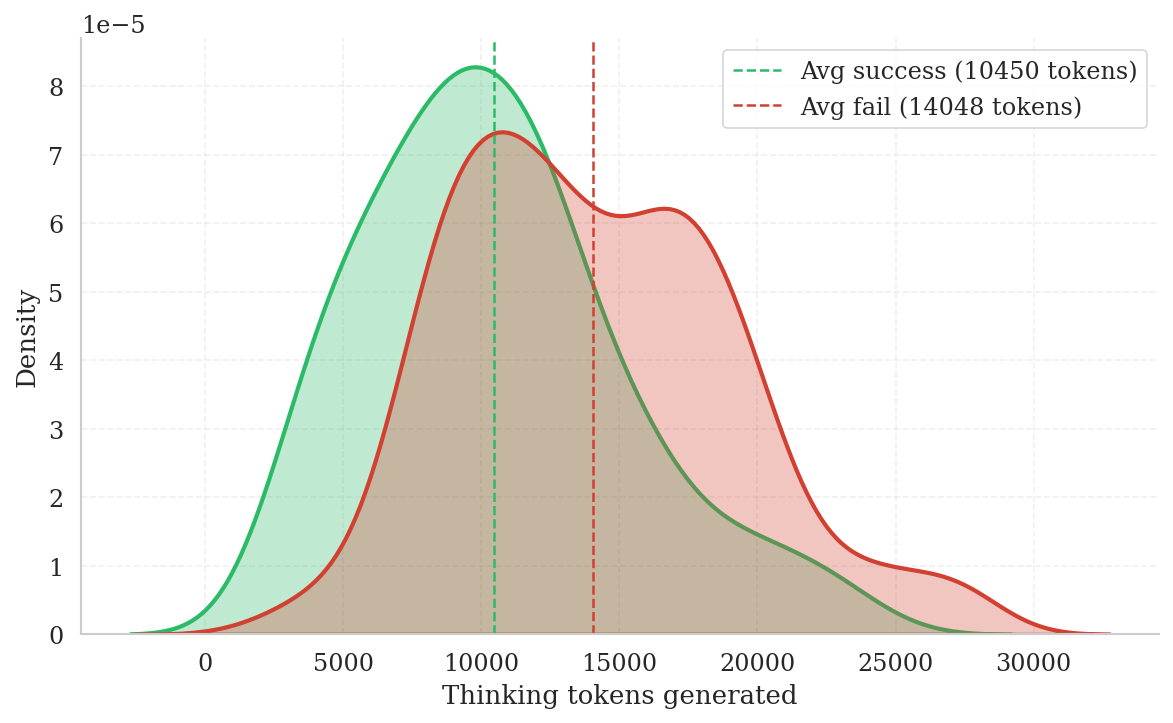

In [ ]:
# thinking tokens

plt.figure(figsize=(8, 5))

# valid attempts only
thinking_df = valid_df[valid_df['Outcome'].isin(['Success', 'Tests failed'])]

# sns.histplot(
#     data=thinking_df, 
#     x="llm_thinking_tokens", 
#     hue="Outcome", 
#     palette={'Success': COLORS['success'], 'Tests failed': COLORS['fail']},
#     element="step", 
#     stat="density", 
#     common_norm=False,
#     alpha=0.3
# )

sns.kdeplot(
    data=thinking_df, 
    x="llm_thinking_tokens", 
    hue="Outcome", 
    palette={'Success': COLORS['success'], 'Tests failed': COLORS['fail']},
    fill=True,
    common_norm=False,    # compares shapes, not counts
    alpha=0.3,
    linewidth=2
)

# mean lines
success_mean = thinking_df[thinking_df['Outcome']=='Success']['llm_thinking_tokens'].mean()
fail_mean = thinking_df[thinking_df['Outcome']=='Tests failed']['llm_thinking_tokens'].mean()

plt.axvline(success_mean, color=COLORS['success'], linestyle='--', label=f'Avg success ({success_mean:.0f} tokens)')
plt.axvline(fail_mean, color=COLORS['fail'], linestyle='--', label=f'Avg fail ({fail_mean:.0f} tokens)')

# plt.title("Thinking token density: success vs. failure", fontweight='bold')
plt.xlabel("Thinking tokens generated")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_thinking_density.pdf")
plt.savefig("figures/fig_thinking_density.png")
plt.show()

In [ ]:
# average tokens used by successful attempts

# filter for successful outcomes only
success_only = valid_df[valid_df['Outcome'] == 'Success']

avg_tokens_success = success_only['llm_total_tokens'].mean()
median_tokens_success = success_only['llm_total_tokens'].median()
total_success_count = len(success_only)

print(f"=== Token Usage for Successful Bug Fixes ===")
print(f"Number of successful attempts: {total_success_count}")
print(f"Average tokens used: {avg_tokens_success:.0f}")
print(f"Median tokens used: {median_tokens_success:.0f}")
print(f"\nFor comparison:")

# compare with failures
fail_only = valid_df[valid_df['Outcome'] == 'Tests failed']
avg_tokens_fail = fail_only['llm_total_tokens'].mean()
print(f"Average tokens (failed attempts): {avg_tokens_fail:.0f}")
print(f"Difference: {avg_tokens_success - avg_tokens_fail:.0f} tokens")

=== Token Usage for Successful Bug Fixes ===
Number of successful attempts: 111
Average tokens used: 16492
Median tokens used: 15205

For comparison:
Average tokens (failed attempts): 21075
Difference: -4583 tokens


In [46]:
# data prep

# success
df['is_success'] = (df['llm_tests_passed_count'] >= df['human_tests_passed_count']) & (df['human_tests_passed_count'] > 0)
df['is_success_int'] = df['is_success'].astype(int)

# melt data for side-by-side complexity comparison
comp_df = df[df['is_success']].melt(
    id_vars=['bug_commit_sha'], 
    value_vars=['complexity_after_human_cognitive', 'complexity_after_llm_cognitive'],
    var_name='Source', value_name='Cognitive complexity'
)
comp_df['Source'] = comp_df['Source'].map({
    'complexity_after_human_cognitive': 'Human',
    'complexity_after_llm_cognitive': 'AI'
})

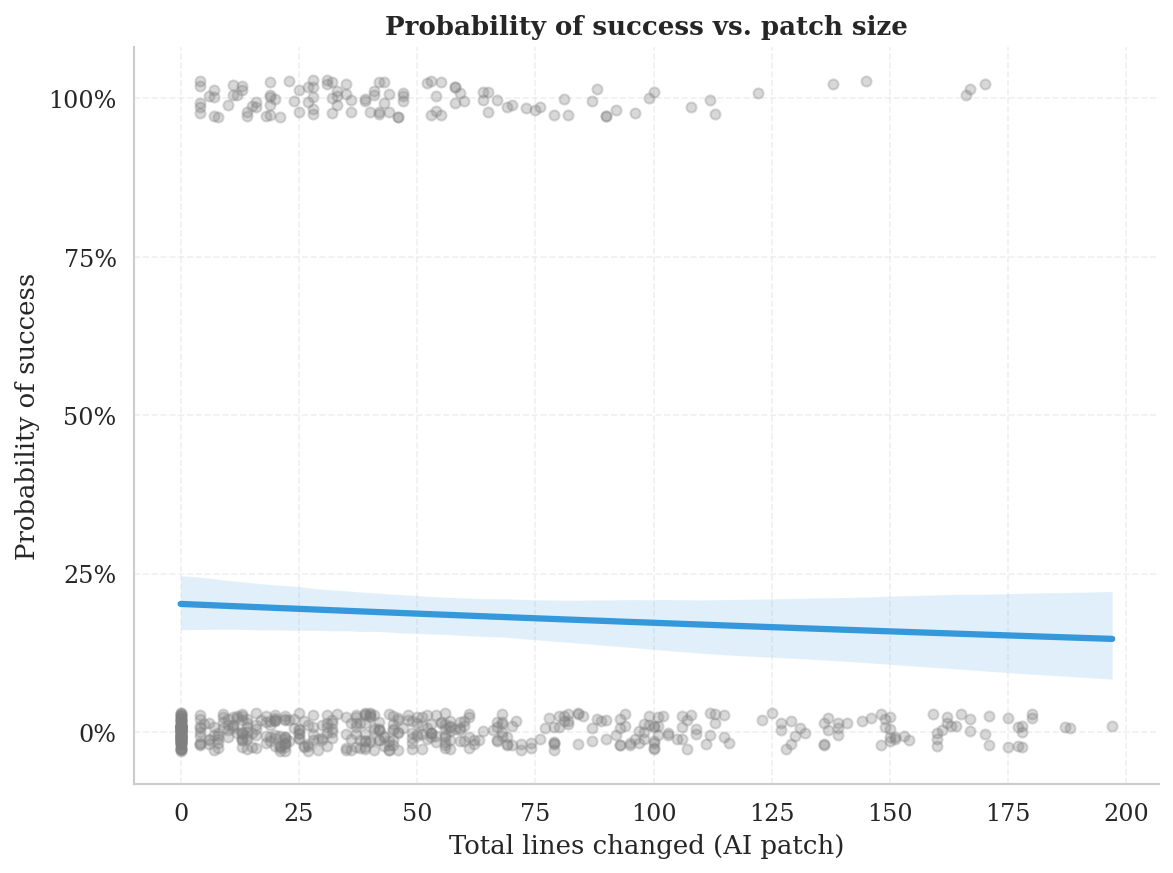

In [ ]:
# patch size vs success
COLORS['primary'] = '#3498db' 

plt.figure(figsize=(8, 6))

# filter outliers for better visualization (patches > 200 lines are rare)
patch_df = df[df['ai_total_diff'] < 200]

sns.regplot(data=patch_df, x='ai_total_diff', y='is_success_int', 
            logistic=True, n_boot=500, y_jitter=0.03,
            scatter_kws={'alpha': 0.3, 'color': 'gray'},
            line_kws={'color': COLORS['primary'], 'linewidth': 3})

plt.title("Probability of success vs. patch size", fontweight='bold')
plt.xlabel("Total lines changed (AI patch)")
plt.ylabel("Probability of success")
plt.yticks([0, 0.25, 0.5, 0.75, 1.0], ['0%', '25%', '50%', '75%', '100%'])

plt.tight_layout()
plt.savefig("figures/fig_patch_size_logistic.pdf")
plt.savefig("figures/fig_patch_size_logistic.png")
plt.show()




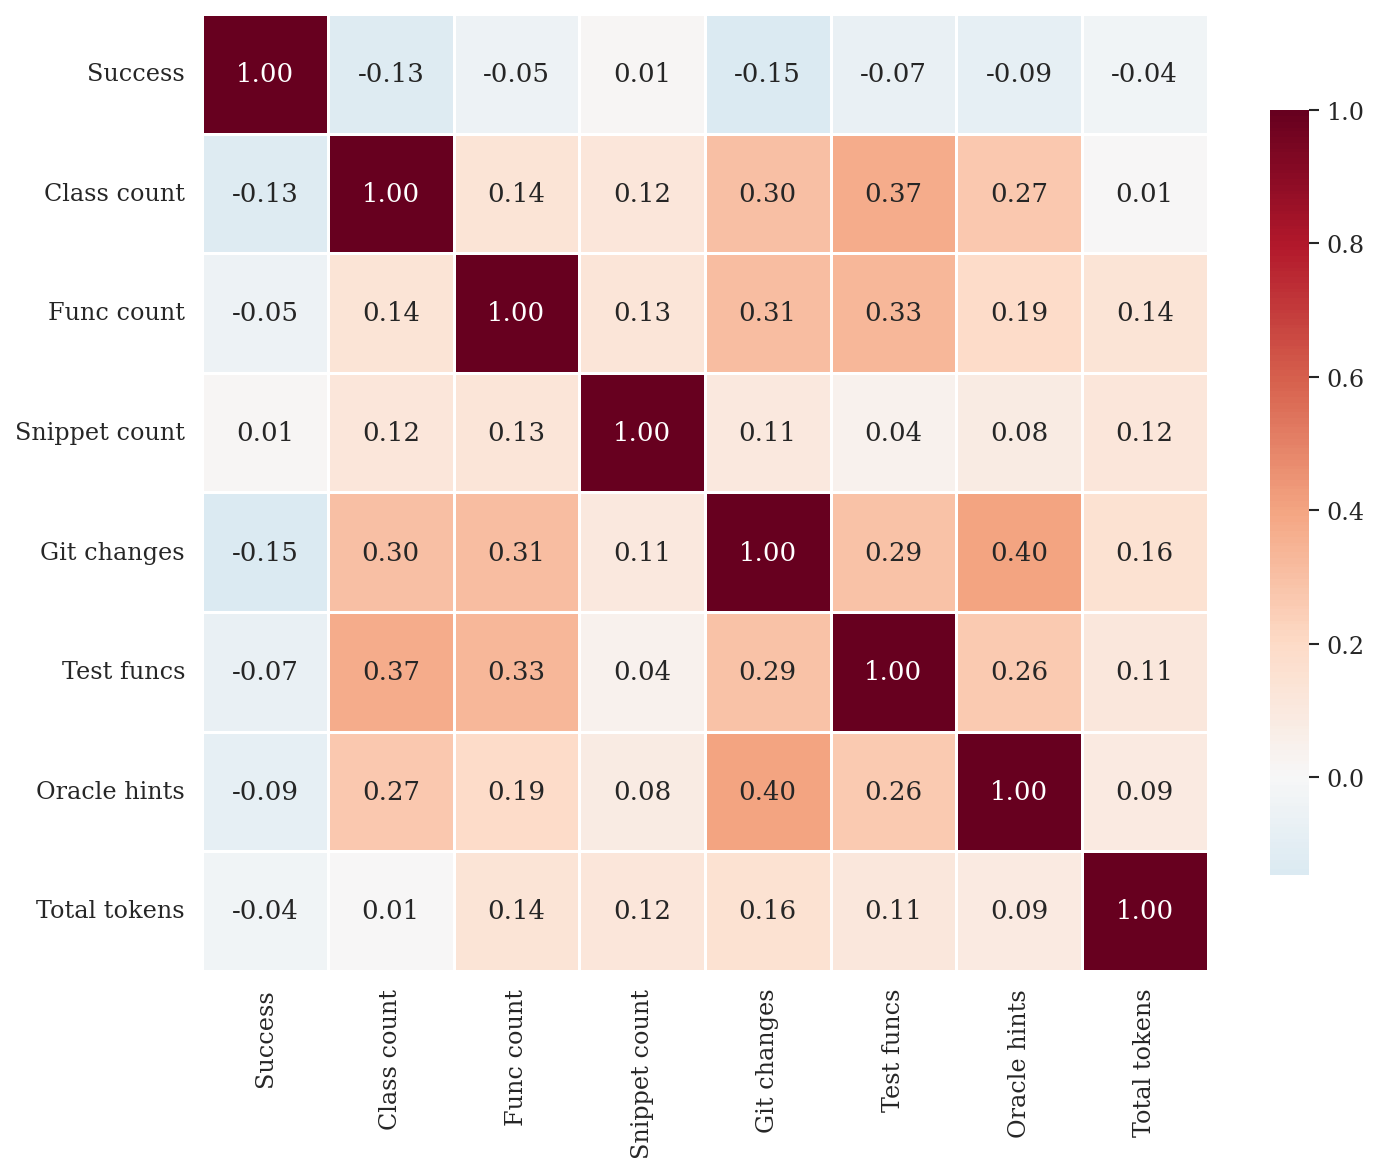

In [ ]:
# context correlation heatmap
plt.figure(figsize=(10, 8))

# interesting context features
features = [
    'is_success_int',
    'context_classes_count', 
    'context_functions_count', 
    'context_snippets_count',
    'context_recent_changes_count',
    'context_test_functions_count',
    'context_oracle_functions_count',
    'llm_total_tokens'
]

corr = df[features].corr()

labels = [
    'Success', 'Class count', 'Func count', 'Snippet count', 
    'Git changes', 'Test funcs', 'Oracle hints', 'Total tokens'
]

sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, cbar_kws={"shrink": .8})

# plt.title("Correlation of context features with success", fontweight='bold')
plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_correlation_matrix.pdf")
plt.savefig("figures/fig_correlation_matrix.png")
plt.show()



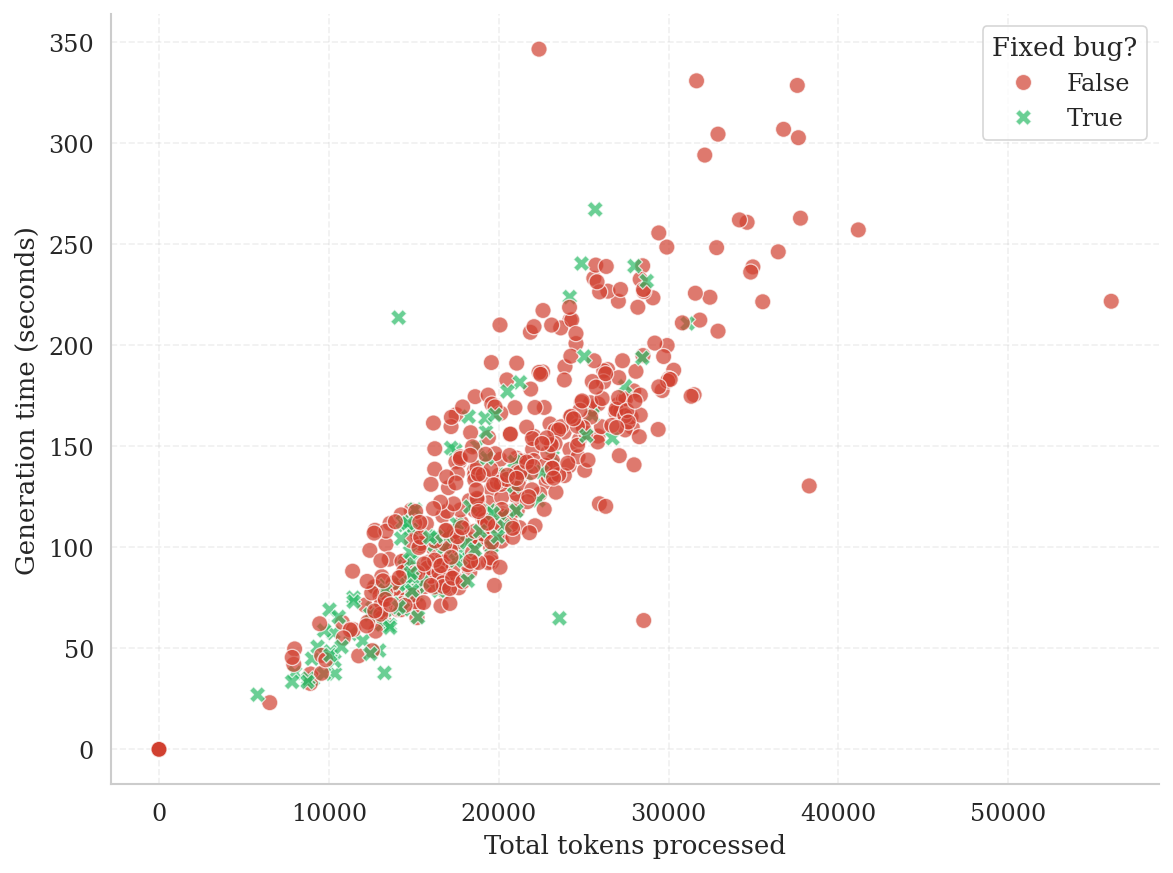

In [50]:

# efficiency scatter: tokens vs time
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='llm_total_tokens', y='llm_generation_time_seconds',
                hue='is_success', style='is_success',
                palette={True: COLORS['success'], False: COLORS['fail']},
                alpha=0.7, s=60)

# plt.title("Efficiency: cost (tokens) vs. latency (time)", fontweight='bold')
plt.xlabel("Total tokens processed")
plt.ylabel("Generation time (seconds)")
plt.legend(title="Fixed bug?")

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_efficiency_scatter.pdf")
plt.savefig("figures/fig_efficiency_scatter.png")
plt.show()

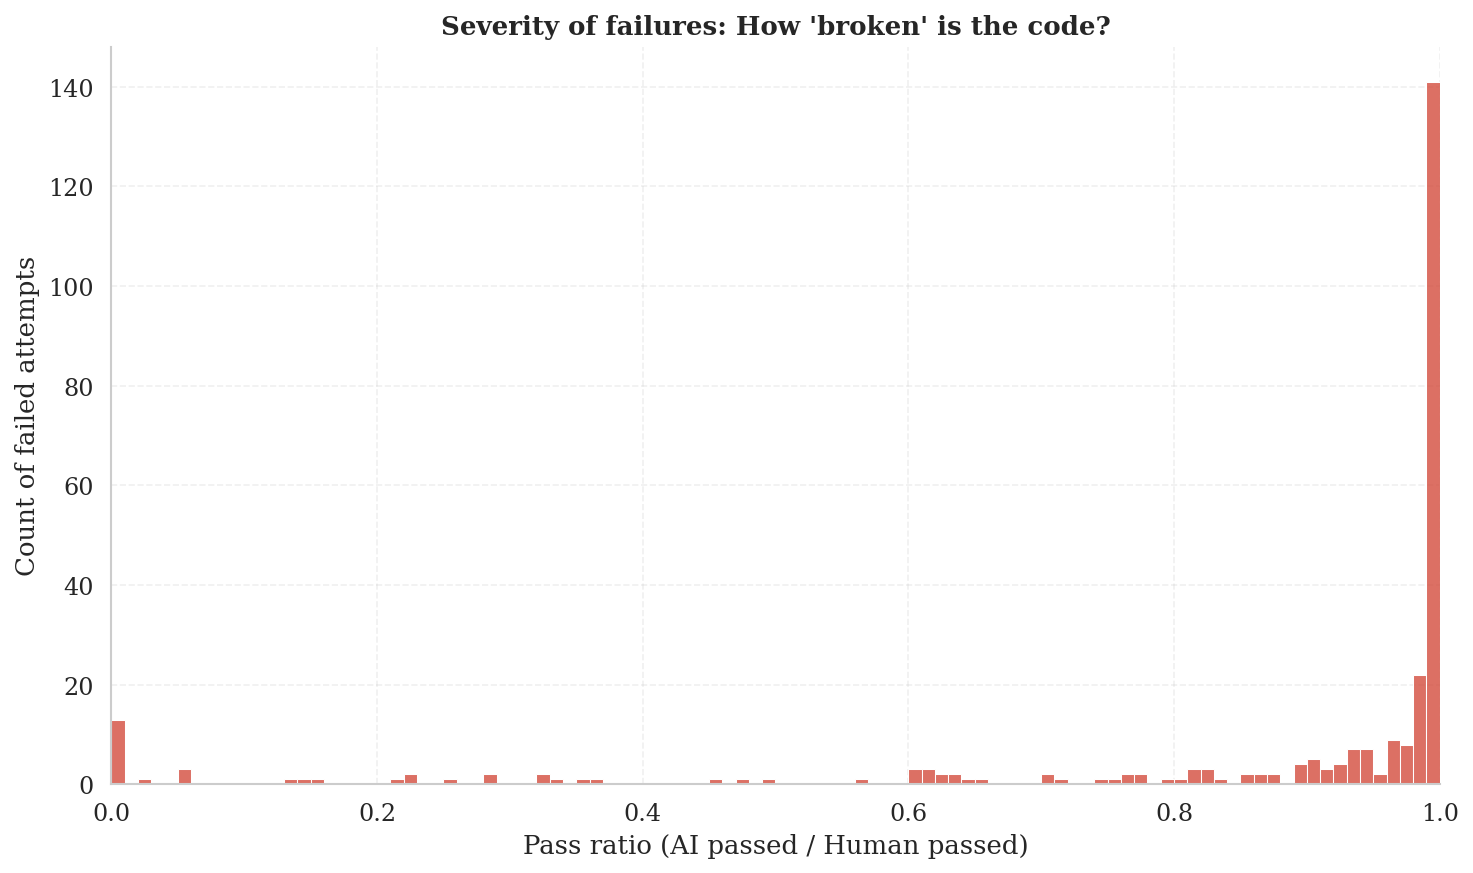

In [ ]:
# near misses

plt.figure(figsize=(10, 6))

# valid runs where outcome is not success
# no dividing by zero goober
fail_df = valid_df[
    (valid_df['Outcome'] == 'Tests failed') & 
    (valid_df['human_tests_passed_count'] > 0)
].copy()

fail_df['pass_ratio'] = fail_df['llm_tests_passed_count'] / fail_df['human_tests_passed_count']

# cap
fail_df['pass_ratio'] = fail_df['pass_ratio'].clip(upper=1.0)

sns.histplot(fail_df, x='pass_ratio', bins=100, color=COLORS['fail'], kde=False)

plt.title("Severity of failures: How 'broken' is the code?", fontweight='bold')
plt.xlabel("Pass ratio (AI passed / Human passed)")
plt.ylabel("Count of failed attempts")
plt.xlim(0, 1.0)

plt.tight_layout()
plt.savefig("figures/fig_failure_severity.pdf")
plt.savefig("figures/fig_failure_severity.png")
plt.show()

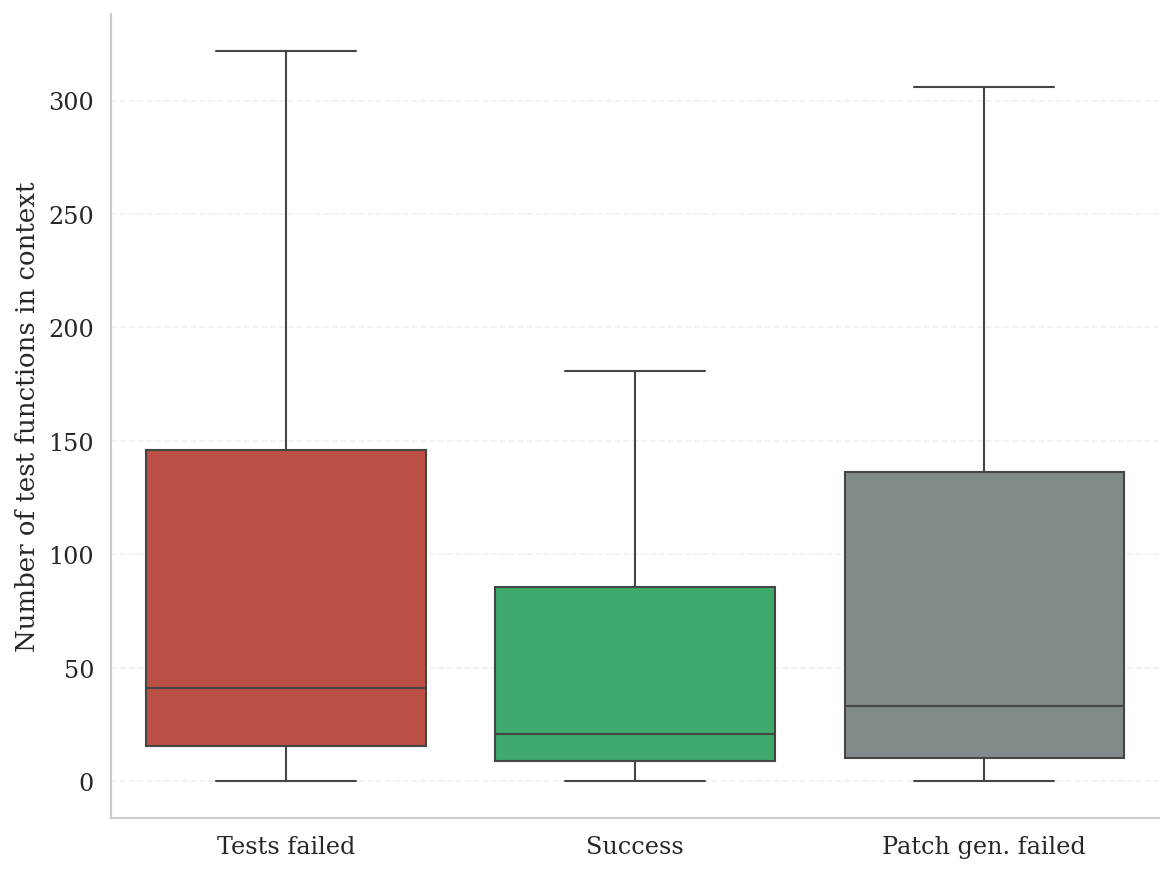

In [52]:
# test context impact

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=valid_df, 
    x='Outcome', 
    y='context_test_functions_count', 
    palette={'Success': COLORS['success'], 'Tests failed': COLORS['fail'], 'Patch gen. failed': COLORS['patch_fail']},
    hue ='Outcome',
    showfliers=False # hide outliers to see the median shift clearly
)

# plt.title("Does providing more tests help?", fontweight='bold')
plt.xlabel("")
plt.ylabel("Number of test functions in context")

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_test_density.pdf")
plt.savefig("figures/fig_test_density.png")
plt.show()

/tmp/ipykernel_25179/93077743.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


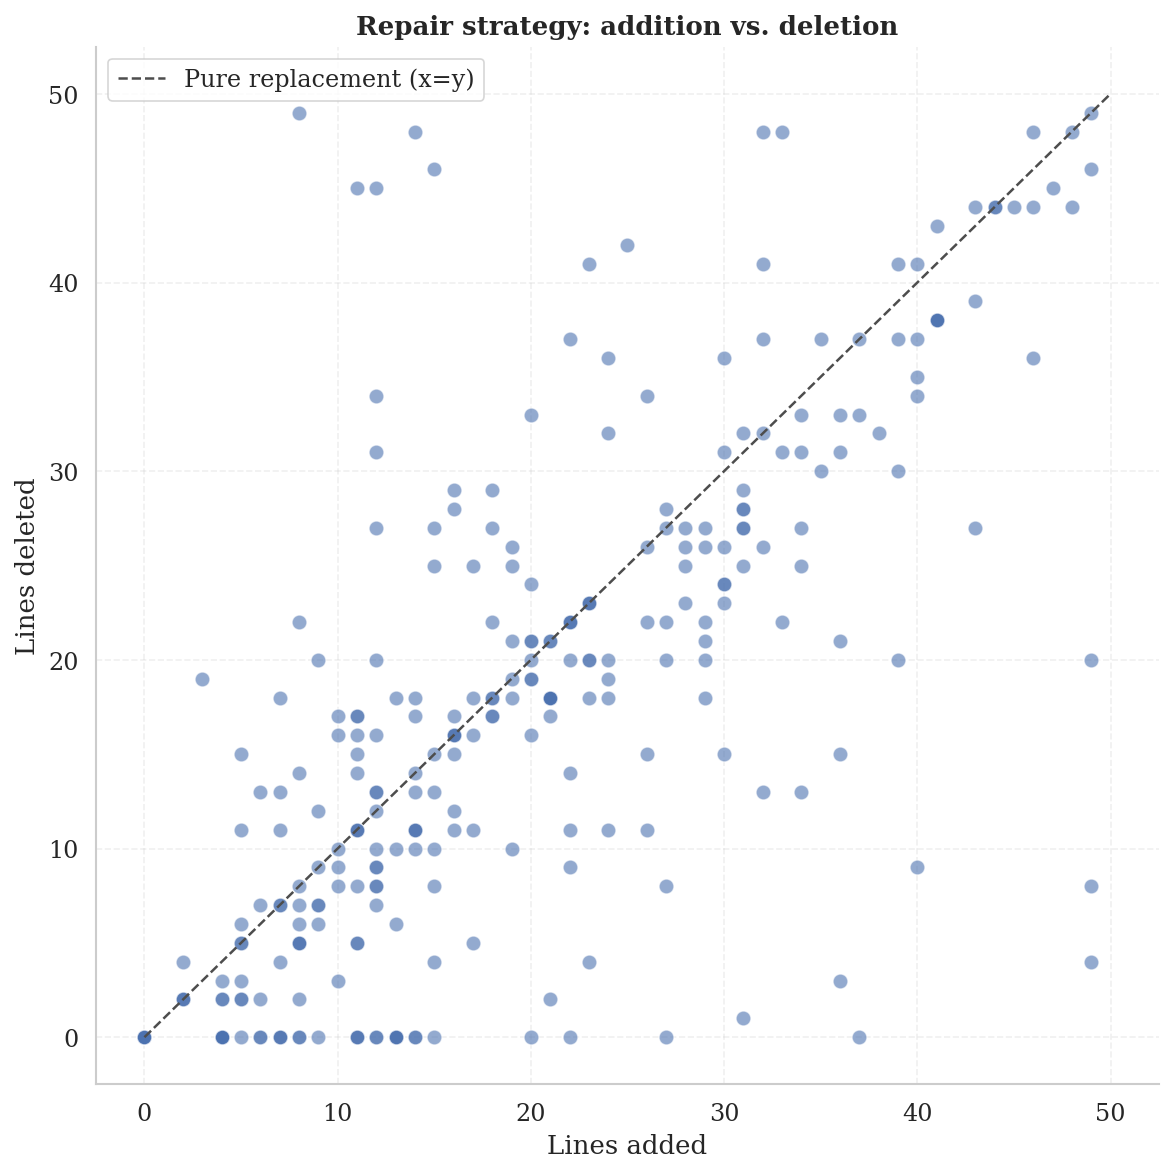

In [53]:
# modification strategy: additions vs deletions

plt.figure(figsize=(8, 8))

# filter outliers for clarity
style_df = valid_df[
    (valid_df['ai_lines_added'] < 50) & 
    (valid_df['ai_lines_deleted'] < 50)
]

sns.scatterplot(
    data=style_df, 
    x='ai_lines_added', 
    y='ai_lines_deleted', 
    palette={'Success': COLORS['success'], 'Tests failed': COLORS['fail']},
    alpha=0.6,
    s=50
)

# diagonal line: replacements
plt.plot([0, 50], [0, 50], ls="--", c=".3", label="Pure replacement (x=y)")

plt.title("Repair strategy: addition vs. deletion", fontweight='bold')
plt.xlabel("Lines added")
plt.ylabel("Lines deleted")
plt.legend()

plt.tight_layout()
plt.savefig("figures/fig_repair_strategy.pdf")
plt.savefig("figures/fig_repair_strategy.png")
plt.show()

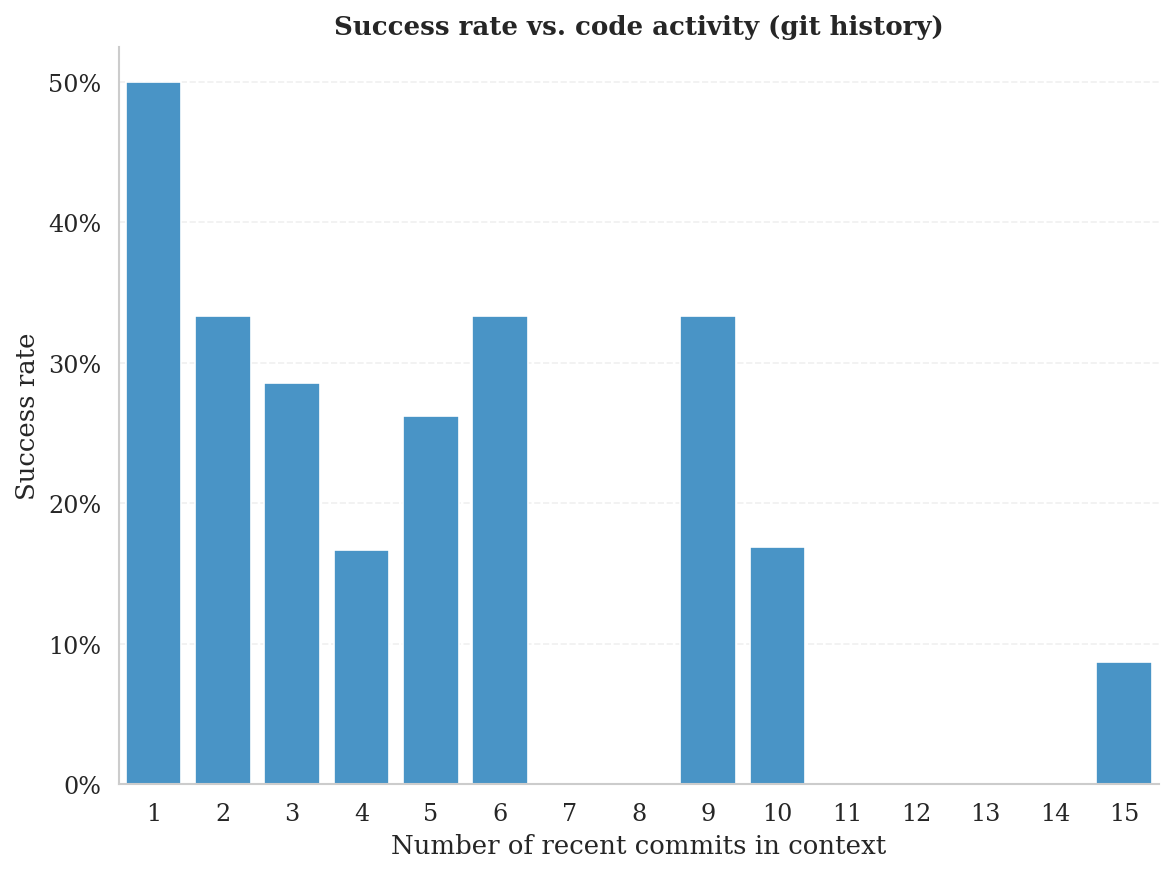

In [ ]:
# historical activity impact

plt.figure(figsize=(8, 6))

# group by how many recent changes were found (0 to 5)
history_stats = valid_df.groupby('context_recent_changes_count')['Outcome'].value_counts(normalize=True).unstack()

# plot only the success rate
if 'Success' in history_stats.columns:
    sns.barplot(x=history_stats.index, y=history_stats['Success'], color=COLORS['primary'])
else:
    print("Warning: No successes found to plot history.")

plt.title("Success rate vs. code activity (git history)", fontweight='bold')
plt.xlabel("Number of recent commits in context")
plt.ylabel("Success rate")
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.savefig("figures/fig_history_impact.pdf")
plt.savefig("figures/fig_history_impact.png")
plt.show()

In [55]:
# merge commit dates

import json
try:
    with open('llm_bug_analysis/corpus.json', 'r') as f:
        corpus_data = json.load(f)
    
    #  mini dataframe of sha -> date
    date_map = pd.DataFrame(corpus_data)[['bug_commit_sha', 'commit_date']]
    
    # 'left' merge to keep all results even if date is missing
    df = df.merge(date_map, on='bug_commit_sha', how='left')
    df['commit_date'] = pd.to_datetime(df['commit_date'], utc=True)
    print("Dates merged successfully.")
    
except FileNotFoundError:
    print("ERROR: corpus.json not found. Cannot analyze dates.")

CUTOFF_DATE = pd.Timestamp("2025-02-01", tz='UTC')

# label
def get_era(row):
    if pd.isnull(row['commit_date']):
        return 'Unknown'
    return 'Pre-cutoff (training data)' if row['commit_date'] < CUTOFF_DATE else 'Post-cutoff (unseen)'

df['Era'] = df.apply(get_era, axis=1)

print("\nSample sizes per era:")
print(df['Era'].value_counts())

Dates merged successfully.

Sample sizes per era:
Era
Pre-cutoff (training data)    541
Post-cutoff (unseen)          148
Name: count, dtype: int64


In [ ]:
# check era distribution
print("Overall success rate:", valid_df['Outcome'].value_counts(normalize=True))
print("\nEra distribution:")
print(df['Era'].value_counts())
print("\nSuccess rate by era:")
print(df.groupby('Era')['Outcome'].value_counts(normalize=True))

Overall success rate: Outcome
Tests failed         0.588358
Success              0.230769
Patch gen. failed    0.180873
Name: proportion, dtype: float64

Era distribution:
Era
Pre-cutoff (training data)    541
Post-cutoff (unseen)          148
Name: count, dtype: int64

Success rate by era (including Unknown):
Era                         Outcome            
Post-cutoff (unseen)        Tests failed           0.662162
                            Success                0.175676
                            Patch gen. failed      0.128378
                            Infrastructure fail    0.033784
Pre-cutoff (training data)  Tests failed           0.408503
                            Infrastructure fail    0.271719
                            Success                0.179298
                            Patch gen. failed      0.140481
Name: proportion, dtype: float64


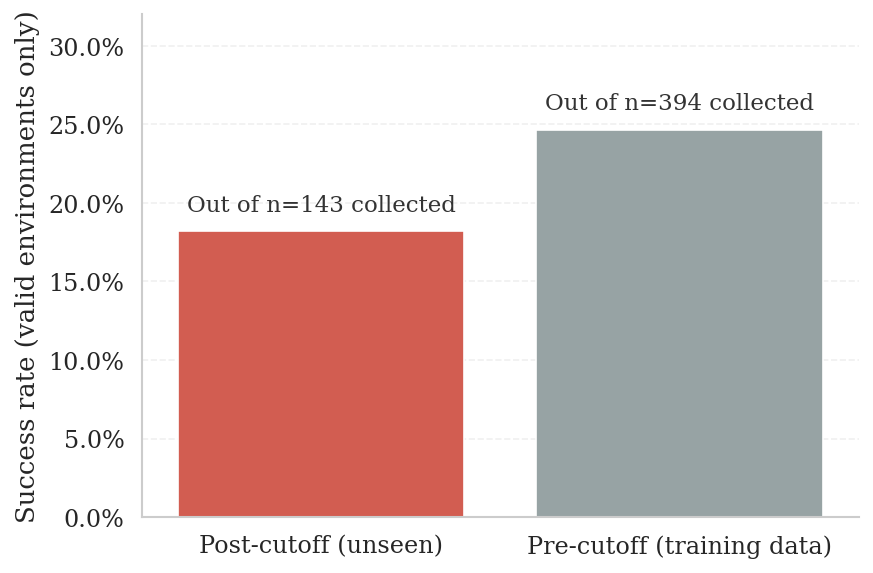

In [ ]:
# contamination analysis plot

plt.figure(figsize=(6, 4))

# filter valid attempts only
# this removes the bias that older repos are harder to install
time_df = df[df['Outcome'] != 'Infrastructure fail'].copy()

# calculate success rates
era_stats = time_df.groupby('Era')['Outcome'].value_counts(normalize=True).unstack()

if 'Success' in era_stats.columns:
    plot_data = time_df.groupby('Era')['Outcome'].apply(lambda x: (x == 'Success').mean()).reset_index()
    plot_data.columns = ['Era', 'Success rate']
 
    plot_data['n'] = time_df.groupby('Era').size().values
    
    ax = sns.barplot(
        data=plot_data, 
        x='Era', 
        y='Success rate', 
        palette={'Pre-cutoff (training data)': '#95a5a6', 'Post-cutoff (unseen)': '#e74c3c'},
        hue='Era'
    )

    # add sample size annotations on top of each bar
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        ax.text(
            i,                           # x pos
            row['Success rate'] + 0.01,  # y pos
            f"Out of n={int(row['n'])} collected",
            ha='center',
            va='bottom',
            fontsize=11,
            color='#333333'
        )

    # plt.title("Generalization check: Did the model memorize fixes?", fontweight='bold')
    plt.ylabel("Success rate (valid environments only)")
    plt.xlabel("")
    
    from matplotlib.ticker import PercentFormatter
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    
    plt.ylim(0, max(plot_data['Success rate']) * 1.3)

    plt.tight_layout()
    plt.savefig("/home/vesco/thesis/latex/figures/fig_contamination_check.pdf")
    plt.savefig("figures/fig_contamination_check.png")
    plt.show()
else:
    print("No successes found in valid set.")

/tmp/ipykernel_25179/3556255902.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


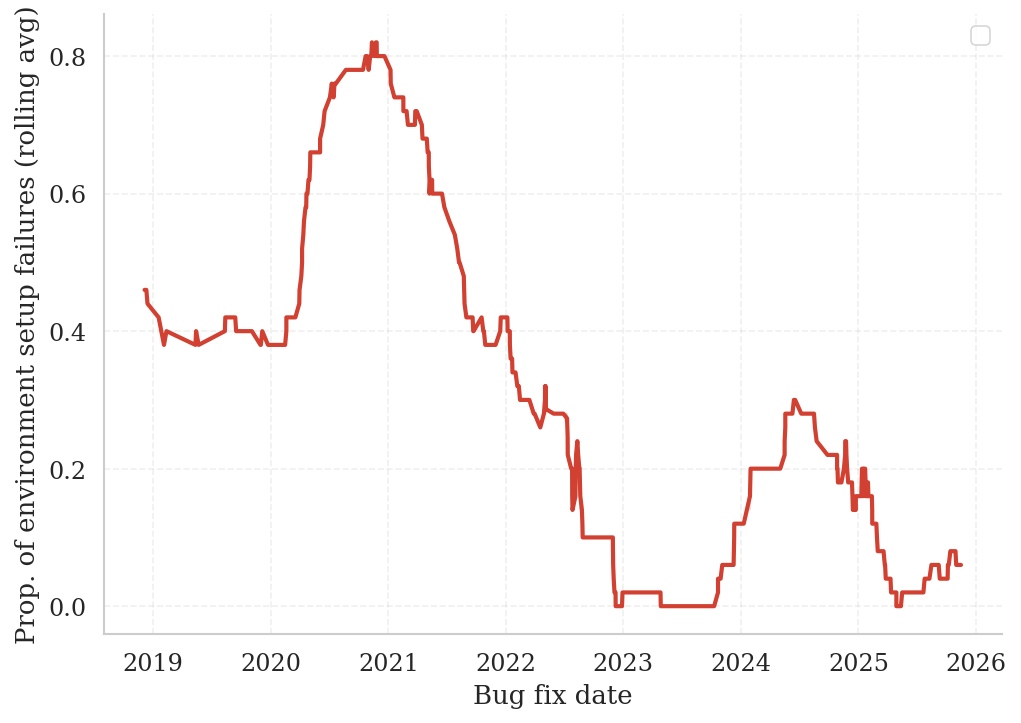

In [65]:
# infra health over time

plt.figure(figsize=(7, 5))

# time-based grouping
# sort by date to make the line chart logical
df_sorted = df.sort_values('commit_date').dropna(subset=['commit_date'])

# convert outcome to binary: 1 = infra fail, 0 = infra ok
df_sorted['is_infra_fail'] = (df_sorted['Outcome'] == 'Infrastructure fail').astype(int)

# rolling average (e.g., window of 50 bugs)
df_sorted['rolling_fail_rate'] = df_sorted['is_infra_fail'].rolling(window=50).mean()

sns.lineplot(data=df_sorted, x='commit_date', y='rolling_fail_rate', color=COLORS['fail'], linewidth=2)

# add cutoff line
# plt.axvline(CUTOFF_DATE, color=COLORS['primary'], linestyle='--', label='Knowledge cutoff (Jan 2025)')

# plt.title("Environment failure rate over time", fontweight='bold')
plt.ylabel("Prop. of environment setup failures (rolling avg)")
plt.xlabel("Bug fix date")
plt.legend()

plt.tight_layout()
plt.savefig("/home/vesco/thesis/latex/figures/fig_infra_rot.pdf")
plt.savefig("figures/fig_infra_rot.png")
plt.show()

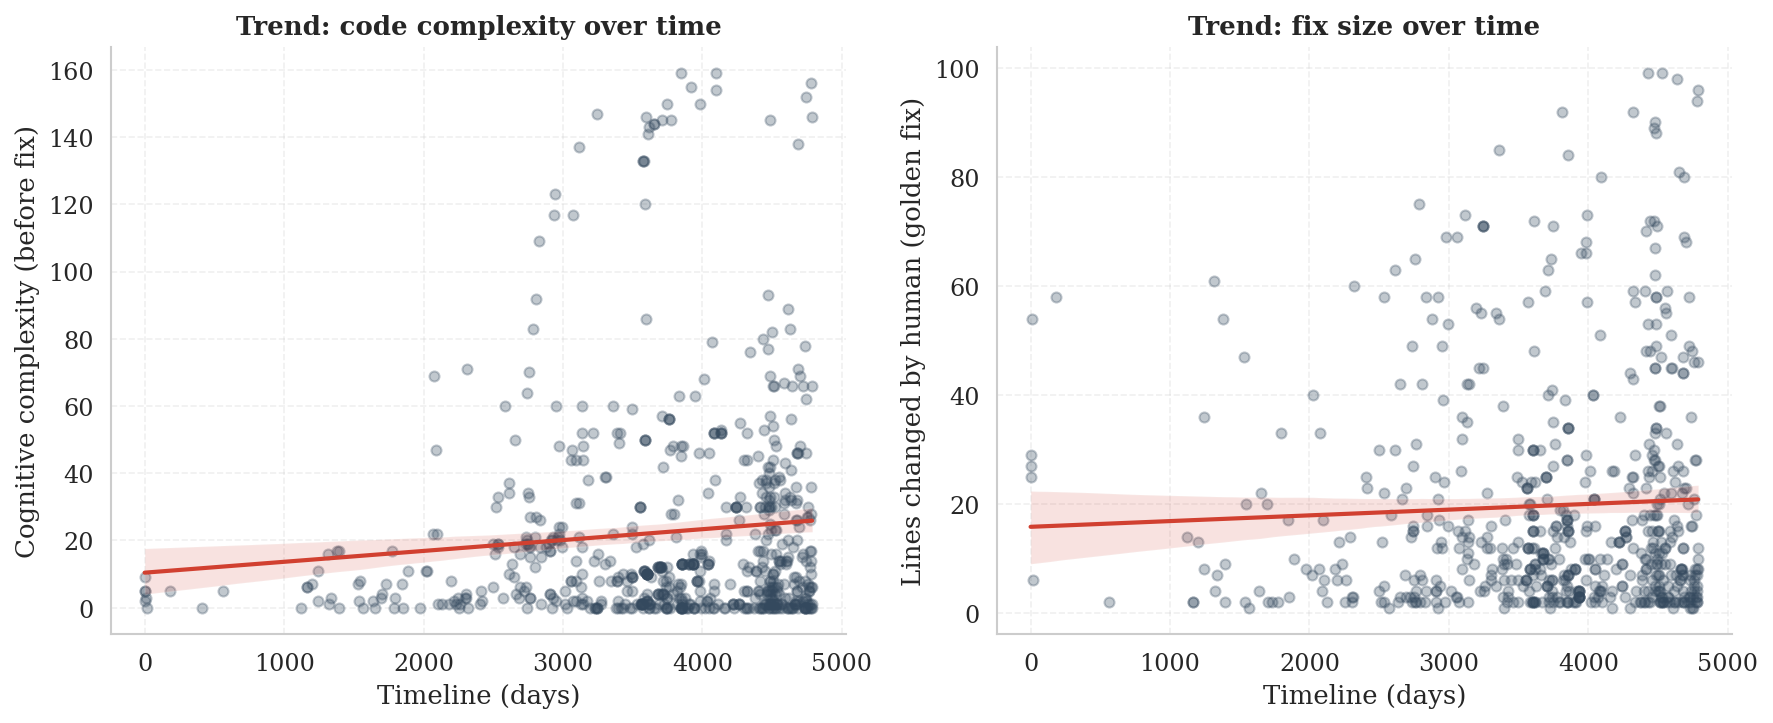

In [59]:
# complexity inflation hypothesis

plt.figure(figsize=(12, 5))

# prepare numeric time representation for regression
# convert dates to "days since first commit in dataset"
min_date = df['commit_date'].min()
df['days_since_start'] = (df['commit_date'] - min_date).dt.days

# input complexity over time
plt.subplot(1, 2, 1)

# filter outliers for clean visualization (top 5% removed)
limit_cc = df['complexity_before_cognitive'].quantile(0.95)
plot_df = df[df['complexity_before_cognitive'] < limit_cc]

sns.regplot(
    data=plot_df, 
    x='days_since_start', 
    y='complexity_before_cognitive',
    scatter_kws={'alpha': 0.3, 'color': COLORS['human']},
    line_kws={'color': COLORS['fail'], 'linewidth': 2}
)

plt.title("Trend: code complexity over time", fontweight='bold')
plt.xlabel("Timeline (days)")
plt.ylabel("Cognitive complexity (before fix)")

# fix size over time
plt.subplot(1, 2, 2)

limit_lines = 100
plot_df_lines = df[df['human_total_diff'] < limit_lines]

sns.regplot(
    data=plot_df_lines, 
    x='days_since_start', 
    y='human_total_diff',
    scatter_kws={'alpha': 0.3, 'color': COLORS['human']},
    line_kws={'color': COLORS['fail'], 'linewidth': 2}
)

plt.title("Trend: fix size over time", fontweight='bold')
plt.xlabel("Timeline (days)")
plt.ylabel("Lines changed by human (golden fix)")

plt.tight_layout()
plt.savefig("figures/fig_complexity_inflation.pdf")
plt.savefig("figures/fig_complexity_inflation.png")
plt.show()

Correlation with time (positive = increases over time):
complexity_before_cognitive         0.078601
complexity_before_cc                0.108533
human_total_diff                    0.036121
context_structural_classes_count    0.016579
Name: days_since_start, dtype: float64


/tmp/ipykernel_25179/66005563.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


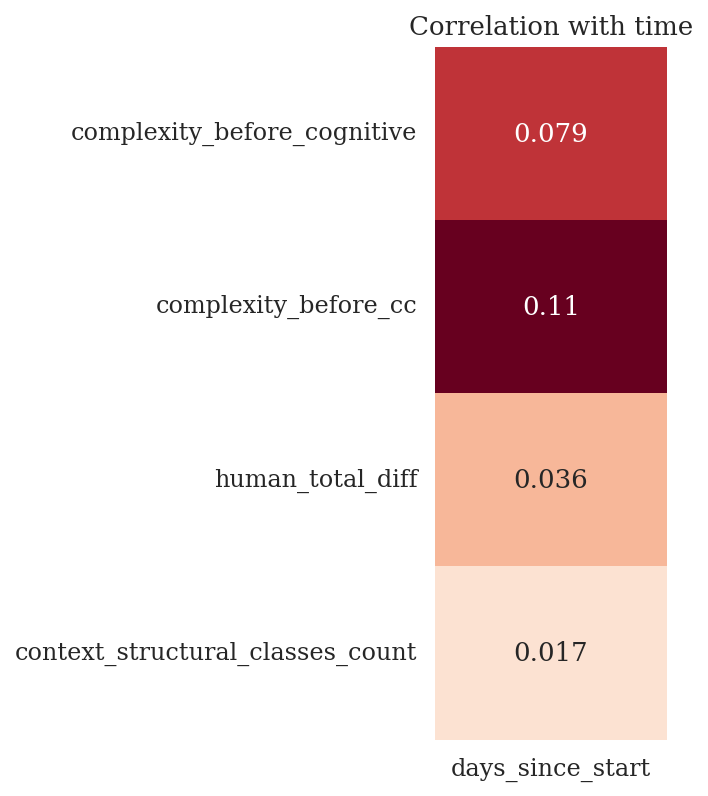

In [60]:
# statistical check

# variables to correlate with time
complexity_metrics = [
    'days_since_start',
    'complexity_before_cognitive',    # how hard is it to understand the file?
    'complexity_before_cc',           # cyclomatic complexity
    'human_total_diff',               # how big is the fix?
    'context_structural_classes_count'# how interconnected is it?
]

time_corr = df[complexity_metrics].corr()['days_since_start'].drop('days_since_start')

print("Correlation with time (positive = increases over time):")
print(time_corr)

# visualize as a simple heatmap
plt.figure(figsize=(2, 6))
sns.heatmap(time_corr.to_frame(), annot=True, cmap='RdBu_r', center=0, cbar=False)
plt.title("Correlation with time")
plt.tight_layout()
plt.show()

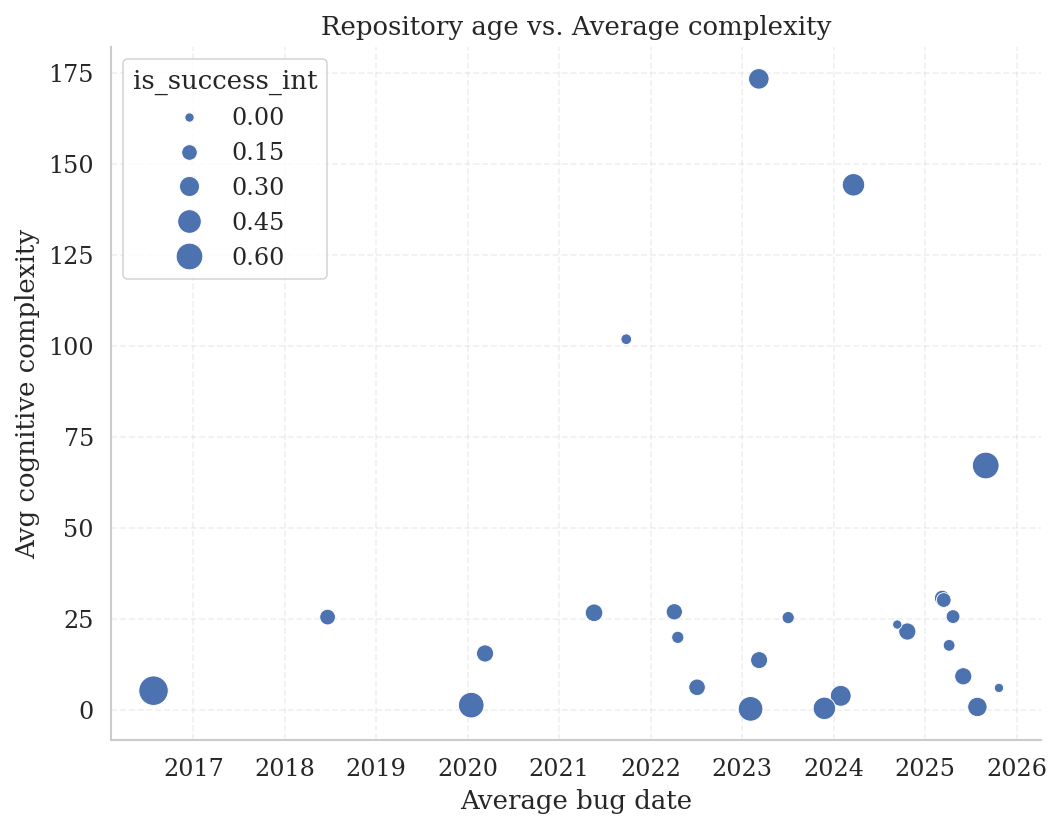

In [61]:
# repos by "modernity"
repo_age = df.groupby('repo_name').agg({
    'commit_date': 'mean',
    'complexity_before_cognitive': 'mean',
    'is_success_int': 'mean'
}).reset_index()

# scatter: modernity vs complexity
plt.figure(figsize=(8, 6))
sns.scatterplot(data=repo_age, x='commit_date', y='complexity_before_cognitive', size='is_success_int', sizes=(20, 200))
plt.title("Repository age vs. Average complexity")
plt.xlabel("Average bug date")
plt.ylabel("Avg cognitive complexity")
plt.show()

--- Top positive correlations with success ---
is_success                  1.000000
is_success_int              1.000000
delta_complexity            0.333463
llm_patch_applied           0.257378
llm_tests_passed            0.222641
human_tests_failed_count    0.172630
human_tests_errors_count    0.136172
llm_tests_skipped_count     0.117799
ai_test_time_seconds        0.078424
llm_tests_passed_count      0.057117
Name: is_success_int, dtype: float64

--- Top negative correlations with success ---
human_lines_deleted                   -0.167559
llm_tests_failed_count                -0.169435
complexity_after_human_cognitive      -0.181296
complexity_after_human_cc             -0.189683
context_classes_count                 -0.192294
context_structural_classes_count      -0.192294
complexity_after_human_total_tokens   -0.195331
context_oracle_functions_count        -0.199972
human_total_diff                      -0.259683
human_lines_added                     -0.277429
Name: is_success_i

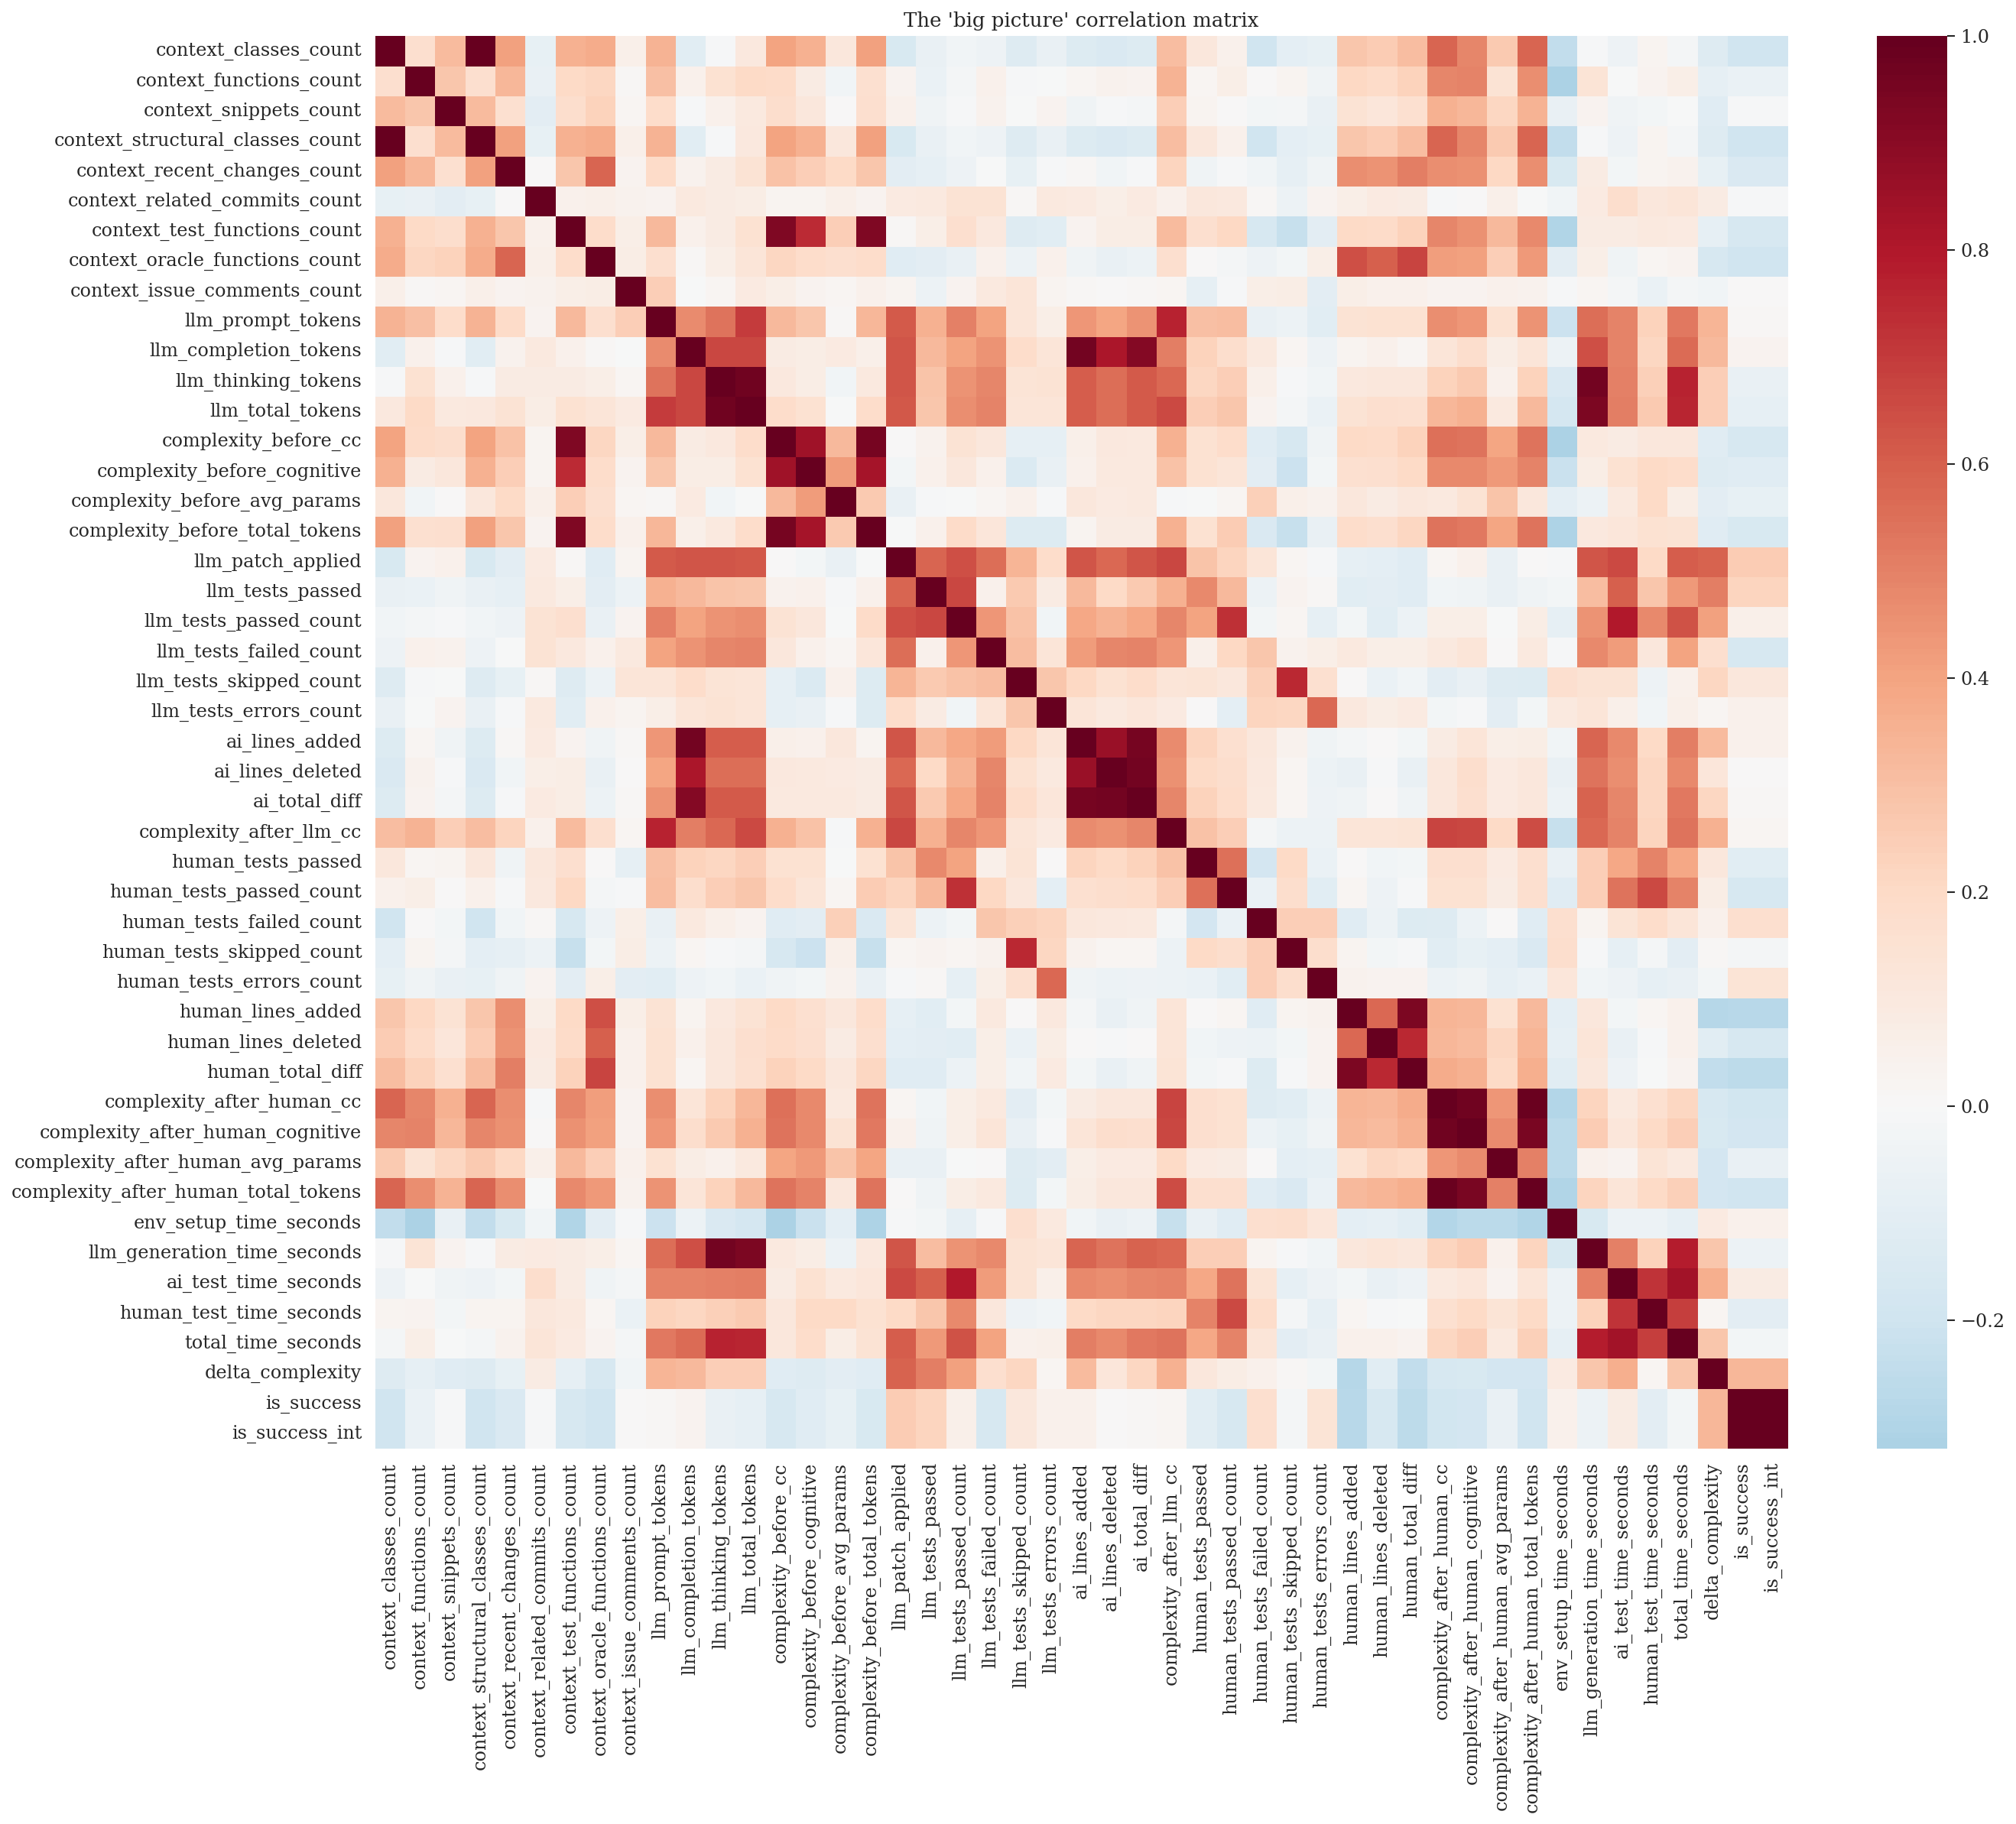

In [62]:
# dragnet - correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

# create is_success columns(before creating numeric_df)
if 'is_success' not in valid_df.columns:
    valid_df['is_success'] = (valid_df['llm_tests_passed_count'] >= valid_df['human_tests_passed_count']) & (valid_df['human_tests_passed_count'] > 0)
    valid_df['is_success_int'] = valid_df['is_success'].astype(int)

# create numeric_df (it will include is_success_int)
numeric_df = valid_df.select_dtypes(include=['float64', 'int64', 'bool']).copy()

# calculate correlation
# spearman for monotonic relationships
# pearson for linear relationships
corr_matrix = numeric_df.corr(method='spearman')

# filter: show only correlations with "success"
target_corr = corr_matrix['is_success_int'].sort_values(ascending=False)

print("--- Top positive correlations with success ---")
print(target_corr.head(10))
print("\n--- Top negative correlations with success ---")
print(target_corr.tail(10))

# full heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False, square=True)
plt.title("The 'big picture' correlation matrix")
plt.show()

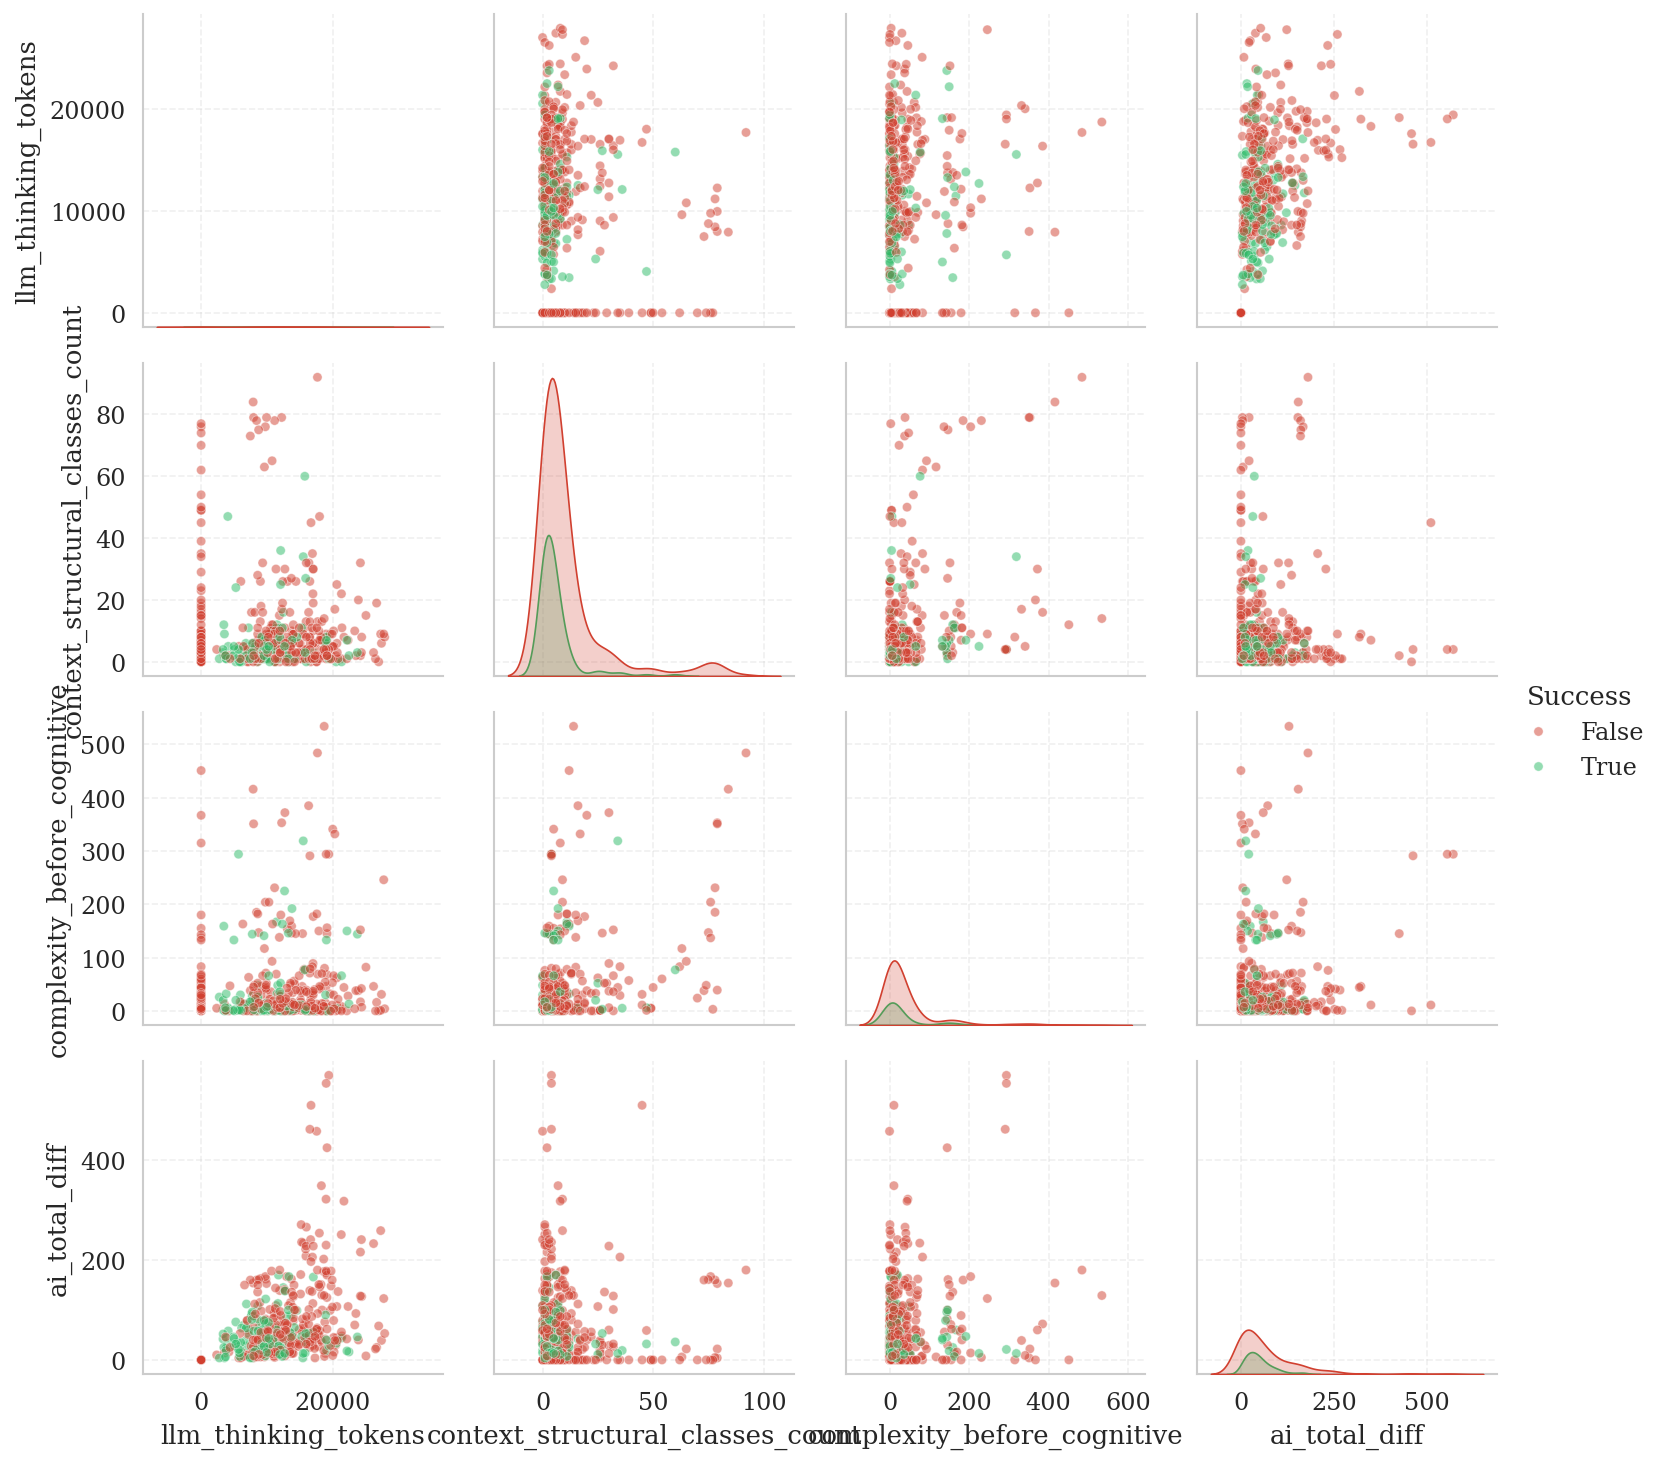

In [63]:
# pair grid

cols_of_interest = [
    'is_success', # the target (color)
    'llm_thinking_tokens',
    'context_structural_classes_count',
    'complexity_before_cognitive',
    'ai_total_diff'
]

g = sns.PairGrid(valid_df[cols_of_interest], hue='is_success', palette={True: COLORS['success'], False: COLORS['fail']})
g.map_diag(sns.kdeplot, fill=True) # diagonals show distribution
g.map_offdiag(sns.scatterplot, s=20, alpha=0.5) # off-diagonals show relationships
g.add_legend(title="Success")
plt.show()

Correlation: bloat vs success: 0.04226002985361171
Correlation: thinking density vs success: 0.09594518126215591


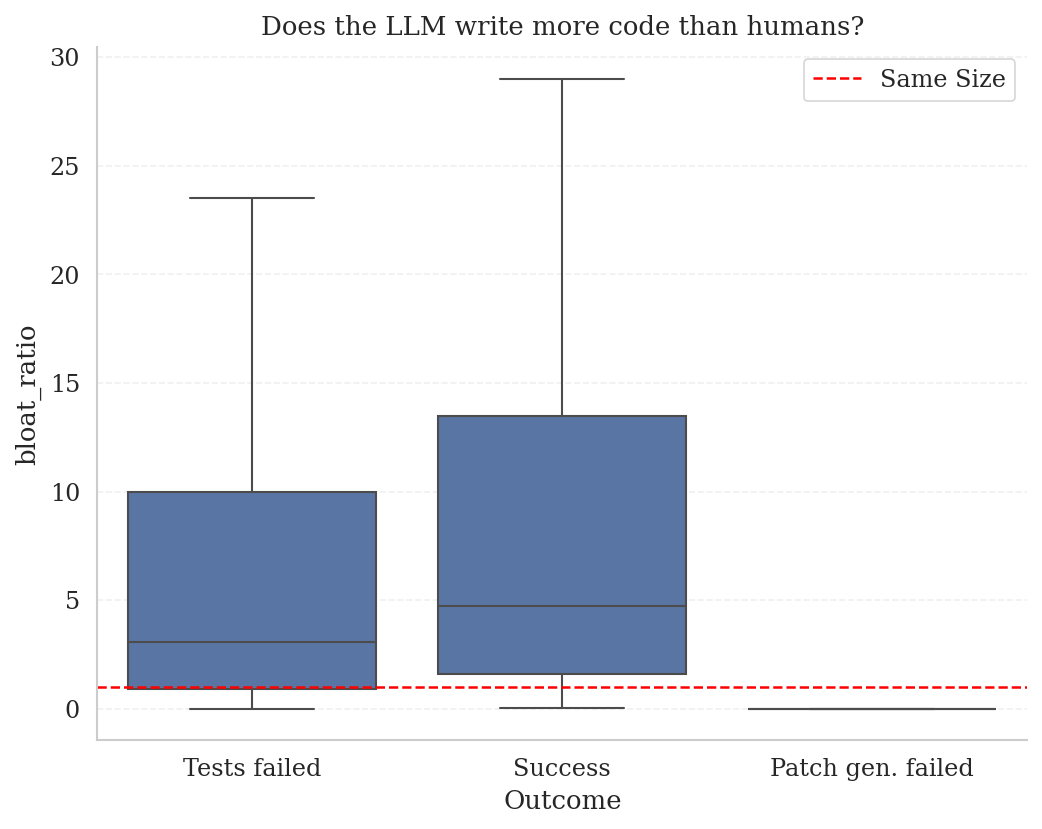

In [ ]:
# is there code bloat?

# no division by zero
valid_df['human_total_diff'] = valid_df['human_total_diff'].replace(0, 1)
valid_df['llm_completion_tokens'] = valid_df['llm_completion_tokens'].replace(0, 1)

# ratios
valid_df['bloat_ratio'] = valid_df['ai_total_diff'] / valid_df['human_total_diff']
valid_df['thinking_density'] = valid_df['llm_thinking_tokens'] / valid_df['llm_completion_tokens']

# check correlations with these new metrics
print("Correlation: bloat vs success:", valid_df['bloat_ratio'].corr(valid_df['is_success_int']))
print("Correlation: thinking density vs success:", valid_df['thinking_density'].corr(valid_df['is_success_int']))

# visualize bloat
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='bloat_ratio', data=valid_df, showfliers=False)
plt.title("Does the LLM write more code than humans?")
plt.axhline(1.0, color='red', linestyle='--', label='Same Size')
plt.legend()
plt.show()